# LLM CV–JD Scoring · Analysis (Levels 1–3)

**Goal:** Evaluate **reliability, validity, and efficiency** of three increasingly transparent LLM scoring designs for CV–JD matching, and compare them on **what they output, cost, and speed**.

## Designs

| Level | Method | LLM output | Score on disk |
|---|---|---|---|
| **Level 1 — Holistic** | LLM reads CV+JD and returns a single fit score | one number + verdict | `score` (0–3) for P0/P1, also `score_100` (0–100) for P2 |
| **Level 2 — Guided categorical** | LLM returns categorical labels per dimension; code maps labels → numeric score with fixed weights | 6 labels (skills, role, domain, edu, holistic, confidence) | `holistic_score` (0–3) and `fit_score_100` (continuous) |
| **Level 3 — Embeddings** *(placeholder)* | Cosine similarity between CV/JD section embeddings | — | — |

## Materials

* **3 CVs** — CV-1 *Assessment Scientist* (`cv_primary`), CV-2 *Head of People* (`cv_hr`), CV-3 *Solution Architect* (`cv_engineer`)
* **2 JD pools** — 32 human-labeled JDs (`main_32`) and extended pool of unlabeled JDs (n=169).
* **3 runs** per (JD × CV × prompt) → test–retest reliability
* **Human holistic labels** available for `cv_primary` × `main_32` only (n = 32)

## Methodology footnotes

When metrics are shown without a column for method, these markers identify the test:

- `*` Spearman ρ (rank correlation, bootstrap 95% CI)

- `**` Wilcoxon signed-rank, rank-biserial *r* effect size, Bonferroni α

- `***` Friedman χ², Kendall's *W* effect size

- `†` RM-ANOVA (Greenhouse–Geisser corrected), partial η² — sensitivity check on continuous scales only

- `‡` Weighted Cohen κ (linear), bootstrap 95% CI

**Notebook scope:** loads pre-computed analysis CSVs only, no API calls.

## 0. Setup

Loads paths, palette and shared CV labels. 

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.precision', 3)

ROOT     = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS  = ROOT / 'results'
ANALYSIS = RESULTS / 'analysis'
FIGURES  = ROOT / 'figures'

# ── Neural Haze palette ──────────────────────────────────────────────────────
VOID       = '#0B0A14'
DEEP_SPACE = '#1C1928'
SLATE      = '#6E6A88'
MIST       = '#C5C3D6'
GHOST      = '#F0EFF8'
ACID_LIME  = '#C8F135'
VIOLET     = '#9B30FF'
CYAN       = '#00F5D4'
MAGENTA    = '#FF2D78'

# CV identifiers and consistent labels/colours across the notebook
CV_KEYS   = ['cv_primary', 'cv_hr', 'cv_engineer']
CV_LABELS = {'cv_primary': 'CV-1  Assessment Scientist',
             'cv_hr':      'CV-2  Head of People',
             'cv_engineer':'CV-3  Solution Architect'}
CV_COLORS = {'cv_primary': ACID_LIME, 'cv_hr': VIOLET, 'cv_engineer': CYAN}

# Score colours (used for 0/1/2/3 score bars)
SCORE_COLORS = [SLATE, CYAN, VIOLET, ACID_LIME]

def style_axes(ax, dark_bg=True):
    """Apply Neural Haze styling to an Axes object."""
    ax.set_facecolor(DEEP_SPACE if dark_bg else VOID)
    ax.tick_params(colors=SLATE)
    for s in ax.spines.values():
        s.set_edgecolor(SLATE)
    ax.grid(axis='y', color=SLATE, linestyle='--', linewidth=0.4, alpha=0.3, zorder=0)
    return ax

print(f'ROOT:     {ROOT}')
print(f'RESULTS:  {RESULTS}')
print(f'ANALYSIS: {ANALYSIS}')

# 1. Level 1 Holistic Scoring

LLM reads CV + JD and returns a single fit score. Three prompt variants:

| Prompt | Description | Outputs |
|---|---|---|
| **P0** | minimal (just a score) | `score` 0–3 + verdict |
| **P1** | rubric prompt with explicit weights | `score` 0–3 + verdict |
| **P2** | rubric + 0–100 production scale | `score` 0–3 + verdict, `score_100` 0–100 |

## 1.1 Dataset overview

Master CSV: one row per LLM call. Each (JD, CV, prompt) combination has 3 runs.

In [21]:
master = pd.read_csv(RESULTS / 'level1_master.csv')
print(f'Unique JDs:    {master["jd_id"].nunique()}')
print(f'Unique CVs:    {master["cv"].nunique()}')
print(f'Total calls:   {len(master)}  (valid: {master["error"].isna().sum()})')

print('\nBreakdown — number of unique JDs per (prompt × cv), run 1:')
master[master['run_id'] == 1].groupby(['prompt', 'cv']).size().unstack(fill_value=0)

Unique JDs:    76
Unique CVs:    3
Total calls:   1260  (valid: 1260)

Breakdown — number of unique JDs per (prompt × cv), run 1:


cv,cv_engineer,cv_hr,cv_primary
prompt,,,
P0,32,32,32
P1,32,32,32
P2,76,76,76


### What kind of JDs are in the pool?

To check the JD pool is **diverse and aligned with the three CV anchors**, each JD title was embedded with `all-MiniLM-L6-v2` (384-dim) and compared to each of the three CV anchor texts (cosine similarity). Pairwise scatter plots show how titles cluster relative to each CV.

* Lime dots — labeled JDs
* Slate dots - unlabeled JDs
* Magenta stars — CV anchors themselves (self-similarity ≈ 1.0)

A diverse JD pool should spread across the plane; titles closest to a CV anchor cluster near that axis.

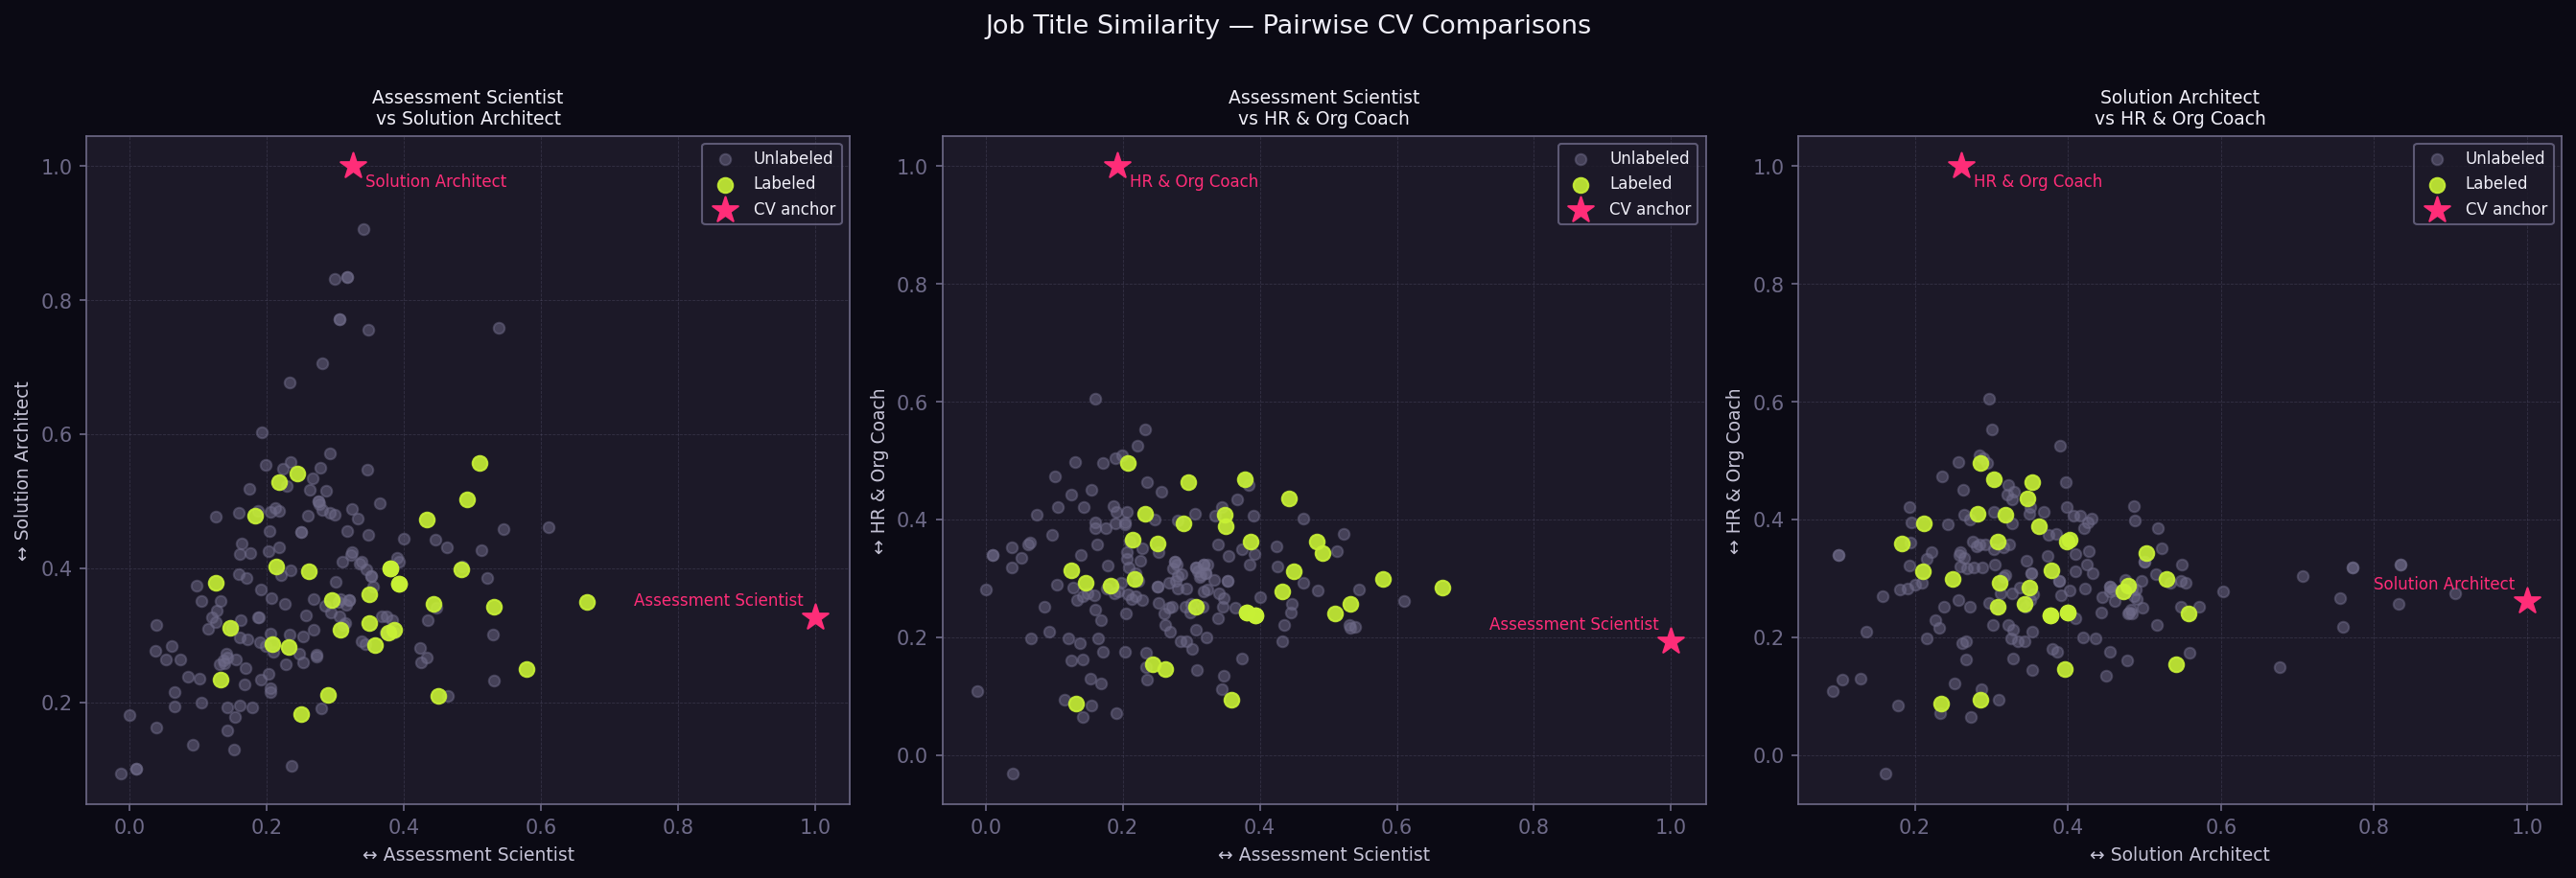

In [22]:
from IPython.display import Image, display
display(Image(ANALYSIS / 'role_title_similarity_pairs.png'))

## 1.2 Score distributions

 With most JDs at score 0 or 1, a perfectly consistent system mostly agrees on “doesn’t fit” — which alone does not prove that the rubric is doing useful work. Score distributions are very similar across prompts. Below is the distribution by CV.

In [30]:
# Load Level 1 data for distribution charts
l1 = pd.read_csv(ROOT / 'results' / 'level1_master.csv')

# Select first run of each (JD, CV, prompt) for cleaner visualization
one_run = l1[l1['run_id'] == 1].copy()

print(f'Using run_id=1 for score distribution visualization (n={len(one_run)})' )

Using run_id=1 for score distribution visualization (n=420)


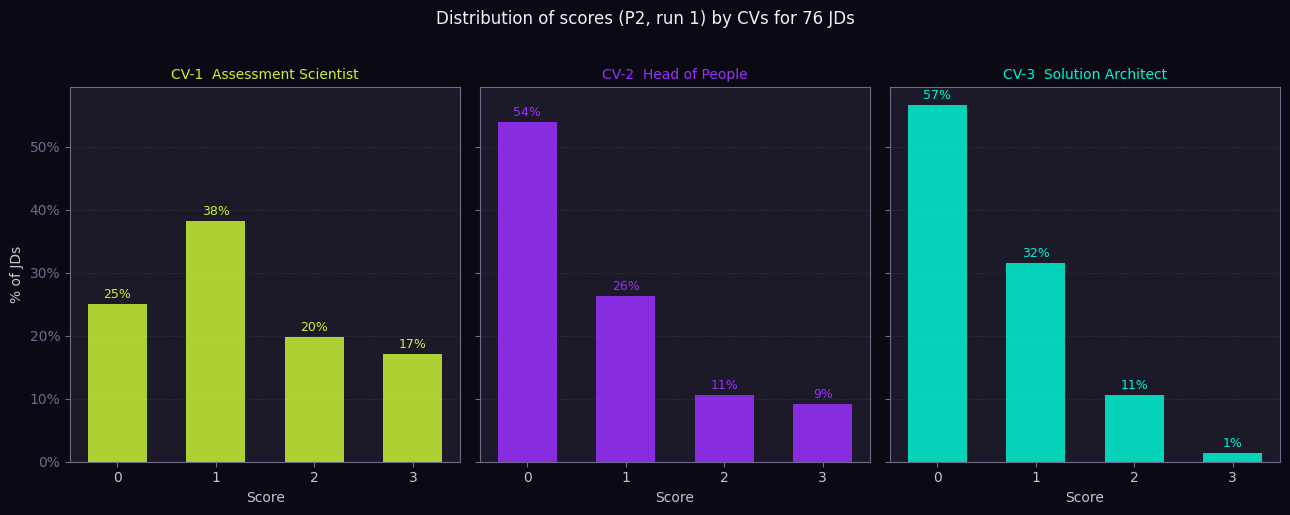

In [31]:
# Chart: P2 score distribution per CV — flip test visual
p2 = one_run[one_run['prompt'] == 'P2']

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.patch.set_facecolor(VOID)

scores = [0, 1, 2, 3]

for ax, cv in zip(axes, CV_KEYS):
    style_axes(ax)
    subset = p2[p2['cv'] == cv]
    counts = [len(subset[subset['score'] == s]) for s in scores]
    total  = sum(counts)
    pcts   = [c / total * 100 for c in counts]
    color  = CV_COLORS[cv]
    bars   = ax.bar(scores, pcts, color=color, alpha=0.85, zorder=2, width=0.6)
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{pct:.0f}%', ha='center', va='bottom', color=color, fontsize=9)
    ax.set_xticks(scores)
    ax.set_xticklabels([str(s) for s in scores], color=MIST)
    ax.set_xlabel('Score', color=MIST)
    ax.set_title(CV_LABELS[cv], color=color, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

axes[0].set_ylabel('% of JDs', color=MIST)
fig.suptitle('Distribution of scores (P2, run 1) by CVs for 76 JDs', color=GHOST, fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig(ANALYSIS / 'dist_p2_by_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Reliability: Test–retest

**Question:** does the system produce the same score when called repeatedly on the same input?

Two ICC indices reported side-by-side because the operational unit matters:
* **ICC(A,1)** — single-measure: reliability of *one* LLM call (what the app actually uses).
* **ICC(A,k)** — average-measure reliability across the 3 repeated runs.
ICC(A,k) is always ≥ ICC(A,1); production decisions rest on ICC(A,1).

Also: **Fleiss κ** + % unanimous + % majority for verdict (categorical). SEM = SD × √(1 − ICC).

**Interpretation:** 
- ICC <0.50 poor / 0.50–0.75 moderate / 0.75–0.90 good / >0.90 **excellent**. 
- κ <0.40 fair / 0.40–0.60 moderate / 0.60–0.80 substantial / >0.80 **almost perfect**.

In [33]:
icc = pd.read_csv(ANALYSIS / 'level1_icc.csv')

print('── Score (0–3) reliability — ICC(A,1) [single call] and ICC(A,k) [mean of 3], CVs pooled ──')
icc[
    (icc['scenario'].str.startswith('score_0-3')) & (icc['cv'] == 'ALL')
][['prompt', 'n_subjects', 'icc_1', 'icc_1_ci_low', 'icc_1_ci_high',
   'value', 'ci_low', 'ci_high', 'sem', 'interpretation']].rename(columns={
    'prompt':'Prompt', 'n_subjects':'N',
    'icc_1':'ICC(A,1)', 'icc_1_ci_low':'CI Low (1)', 'icc_1_ci_high':'CI High (1)',
    'value':'ICC(A,k)', 'ci_low':'CI Low (k)', 'ci_high':'CI High (k)',
    'sem':'SEM', 'interpretation':'Interp.',
})

── Score (0–3) reliability — ICC(A,1) [single call] and ICC(A,k) [mean of 3], CVs pooled ──


,Prompt,N,"ICC(A,1)",CI Low (1),CI High (1),"ICC(A,k)",CI Low (k),CI High (k),SEM,Interp.
0,P0,96,0.953,0.94,0.97,0.984,0.98,0.99,0.124,excellent
1,P1,96,0.971,0.96,0.98,0.990,0.99,0.99,0.097,excellent
2,P2,228,0.984,0.98,0.99,0.995,0.99,1.00,0.070,excellent


In [34]:
print('── Verdict agreement (Fleiss κ + % unanimous + % majority) ──')

icc[
    (icc['scenario'].str.startswith('verdict')) &
    (icc['cv'] == 'ALL')
][
    ['prompt', 'n_subjects', 'value', 'pct_unanimous', 'pct_majority', 'interpretation']
].rename(columns={
    'prompt': 'Prompt',
    'n_subjects': 'N',
    'value': 'Fleiss κ',
    'pct_unanimous': '% Unanimous',
    'pct_majority': '% Majority',
    'interpretation': 'Interpretation'
})

── Verdict agreement (Fleiss κ + % unanimous + % majority) ──


,Prompt,N,Fleiss κ,% Unanimous,% Majority,Interpretation
16,P0,96,0.913,93.8,100.0,almost perfect
17,P1,96,0.956,96.9,100.0,almost perfect
18,P2,228,0.968,98.2,100.0,almost perfect


In [35]:
print('── Score (0–100) reliability — ICC(A,1) [single call] and ICC(A,k), CVs pooled ──')
icc[
    (icc['scenario'].str.startswith('score_0-100')) & (icc['cv'] == 'ALL')
][['prompt', 'n_subjects', 'icc_1', 'icc_1_ci_low', 'icc_1_ci_high',
   'value', 'ci_low', 'ci_high', 'sem', 'interpretation']].rename(columns={
    'prompt':'Prompt', 'n_subjects':'N',
    'icc_1':'ICC(A,1)', 'icc_1_ci_low':'CI Low (1)', 'icc_1_ci_high':'CI High (1)',
    'value':'ICC(A,k)', 'ci_low':'CI Low (k)', 'ci_high':'CI High (k)',
    'sem':'SEM', 'interpretation':'Interp.',
})

── Score (0–100) reliability — ICC(A,1) [single call] and ICC(A,k), CVs pooled ──


,Prompt,N,"ICC(A,1)",CI Low (1),CI High (1),"ICC(A,k)",CI Low (k),CI High (k),SEM,Interp.
12,P2,228,0.992,0.99,0.99,0.997,1.0,1.0,1.355,excellent


### Reliability — key findings

* **All prompts excellent.** ICC(A,1) — the single-call reliability that matters in production — is 0.95 (P0) / 0.97 (P1) / 0.98 (P2) on 0–3, and 0.98 on the P2 0–100 scale. ICC(A,k) over 3 runs is correspondingly 0.98–0.995. Verdict agreement is almost perfect (Fleiss κ 0.91–0.97).
* **Rubric helps slightly**: P1 > P0 on both ICC indices. Adding the 0–100 scale (P2) gains another notch.
* **cv_engineer is the weakest cell** of the heatmap: most engineer-JD pairs cluster at score 0, so the rating *agrees on doesn't-fit*. High ICC here is partly a ceiling artefact of the compressed 0–3 scale under restricted variance — reproducibility, not informativeness.
* **Caveat (scale-dependent):** ICCs on the compressed 0–3 scale are likely inflated relative to a wider scale. Focus on the relative ordering (P0 < P1 < P2), not the absolute ICC values.

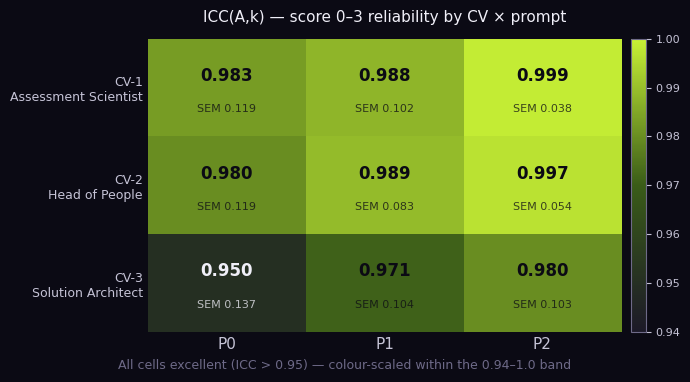

In [10]:
# Heatmap: ICC(A,k) for score 0–3, by CV × prompt (visualises Engineer-CV bottleneck)
sub = icc[icc['scenario'].str.startswith('score_0-3') & (icc['cv'] != 'ALL')].copy()

prompts = ['P0', 'P1', 'P2']
icc_grid = np.zeros((3, 3))
sem_grid = np.zeros((3, 3))
for r, cv in enumerate(CV_KEYS):
    for c, prompt in enumerate(prompts):
        row = sub[(sub['cv'] == cv) & (sub['prompt'] == prompt)]
        if len(row):
            icc_grid[r, c] = row['value'].values[0]
            sem_grid[r, c] = row['sem'].values[0]

vmin, vmax = 0.94, 1.0
cmap = mcolors.LinearSegmentedColormap.from_list('nh', [DEEP_SPACE, '#3A5C18', ACID_LIME])

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(VOID); ax.set_facecolor(VOID)
im = ax.imshow(icc_grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

for r in range(3):
    for c in range(3):
        val = icc_grid[r, c]; sem = sem_grid[r, c]
        text_color = VOID if val > 0.97 else GHOST
        ax.text(c, r - 0.12, f'{val:.3f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=text_color)
        ax.text(c, r + 0.22, f'SEM {sem:.3f}', ha='center', va='center',
                fontsize=8, color=text_color, alpha=0.75)

ax.set_xticks(range(3)); ax.set_xticklabels(prompts, color=MIST, fontsize=11)
ax.set_yticks(range(3))
ax.set_yticklabels([CV_LABELS[cv].replace('  ', '\n') for cv in CV_KEYS], color=MIST, fontsize=9)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(colors=MIST, labelsize=8); cbar.outline.set_edgecolor(SLATE)

ax.set_title('ICC(A,k) — score 0–3 reliability by CV × prompt', color=GHOST, fontsize=11, pad=12)
fig.suptitle('All cells excellent (ICC > 0.95) — colour-scaled within the 0.94–1.0 band', color=SLATE, fontsize=9, y=0.02)

plt.tight_layout()
plt.savefig(ANALYSIS / 'icc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Criterion validity: LLM vs human scores

**Question:** does the LLM score agree with human judgment?

Available only for Assessment Scientist CV × 32 main JDs.

**Order of evidence:**
1. **Agreement** — % exact match, % within ±1, MAE.
   *Note:* ±1 spans 67 % of a 4-point scale, so this metric is **lenient by construction**. Exact match is the stricter view.
2. **Ordinal-scale agreement** — Weighted Cohen κ‡ (linear weights, bootstrap 95 % CI). The scale-appropriate statistic for a 4-level ordinal criterion.
3. **Rank correlation** — Spearman ρ\*  (ordinal × ordinal).
4. **Where it disagrees** — confusion matrix (verdict mode of 3 runs vs human-derived verdict).

In [98]:
# Summary table: L1 validity against human labels (scale 0–3, n=32)
val = pd.read_csv(ANALYSIS / 'level1_validity.csv')

def fmt_pct(v): return f'{v:.1f}%'
def fmt_3(v):   return f'{v:.3f}'
def fmt_bias(v): return f'+{v:.2f}' if v >= 0 else f'{v:.2f}'

rows = []
for prompt in ['P0', 'P1', 'P2']:
    sub = val[(val['prompt'] == prompt) & (val['scale'] == 'holistic_score_0-3')]
    def get(metric):
        r = sub[sub['metric'] == metric]
        return r['value'].values[0] if len(r) else np.nan
    rows.append({
        'Prompt':            f'L1 {prompt}',
        'Spearman ρ':        fmt_3(get('Spearman ρ')),
        'Weighted κ':        fmt_3(get('Weighted κ')),
        'MAE ↓':             fmt_3(get('MAE')),
        'Bias (LLM−human)':  fmt_bias(get('Bias (LLM−human)')),
        'Exact match':       fmt_pct(get('% exact match')),
    })

summary_df = pd.DataFrame(rows)
print('── L1 validity vs human labels (n=32, holistic score 0–3) ──')
display(summary_df)

── L1 validity vs human labels (n=32, holistic score 0–3) ──


,Prompt,Spearman ρ,Weighted κ,MAE ↓,Bias (LLM−human),Exact match
0,L1 P0,0.823,0.520,0.562,+0.44,46.9%
1,L1 P1,0.821,0.514,0.594,+0.47,43.8%
2,L1 P2,0.849,0.623,0.469,+0.41,56.2%


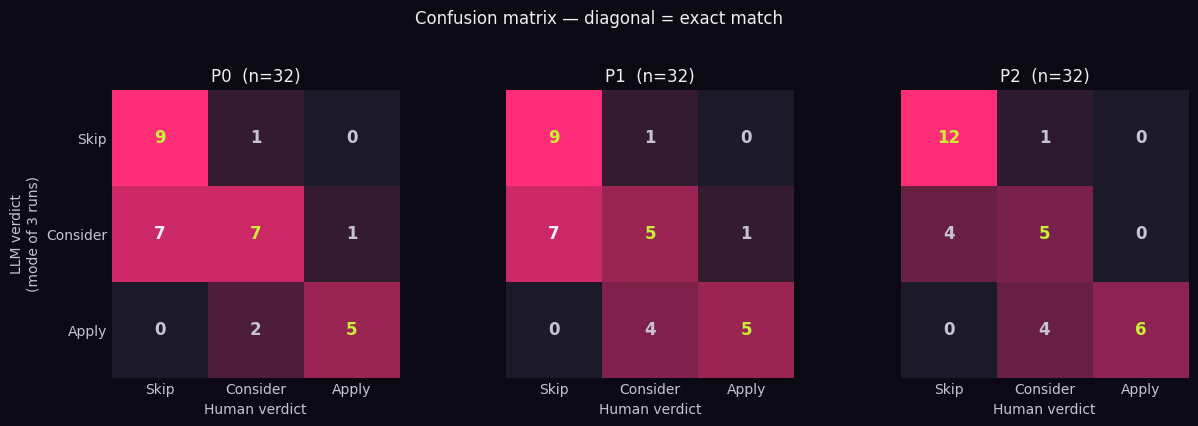

In [13]:
# ── 3. Confusion heatmap — where LLM verdict disagrees with human ───────────
VERDICT_ORDER = ['Skip', 'Consider', 'Apply']

def human_to_verdict(s):
    return {3: 'Apply', 2: 'Consider'}.get(int(s), 'Skip')

primary_main = master[
    (master['cv'] == 'cv_primary') & master['human_holistic_label'].notna()
].copy()

# aggregate to one verdict per (jd, prompt) using mode of 3 runs
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.patch.set_facecolor(VOID)

for ax, prompt in zip(axes, ['P0', 'P1', 'P2']):
    sub = primary_main[primary_main['prompt'] == prompt]
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', color=MIST, transform=ax.transAxes, ha='center')
        continue
    agg = sub.groupby('jd_id').agg(
        llm_verdict   = ('verdict', lambda x: x.mode().iloc[0]),
        human_score   = ('human_holistic_label', 'first'),
    ).reset_index()
    agg['human_verdict'] = agg['human_score'].apply(human_to_verdict)
    cm = pd.crosstab(agg['llm_verdict'], agg['human_verdict']).reindex(
        index=VERDICT_ORDER, columns=VERDICT_ORDER, fill_value=0)

    ax.set_facecolor(VOID)
    cmap = mcolors.LinearSegmentedColormap.from_list('nh', [DEEP_SPACE, MAGENTA])
    im = ax.imshow(cm.values, cmap=cmap, vmin=0, vmax=cm.values.max())
    for i in range(3):
        for j in range(3):
            v = cm.values[i, j]
            on_diag = (i == j)
            color = ACID_LIME if on_diag and v > 0 else (GHOST if v > cm.values.max() / 2 else MIST)
            ax.text(j, i, str(v), ha='center', va='center',
                    color=color, fontsize=12, fontweight='bold')
    ax.set_xticks(range(3)); ax.set_xticklabels(VERDICT_ORDER, color=MIST)
    ax.set_yticks(range(3)); ax.set_yticklabels(VERDICT_ORDER, color=MIST)
    ax.set_xlabel('Human verdict', color=MIST)
    ax.set_title(f'{prompt}  (n=32)', color=GHOST)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0)

axes[0].set_ylabel('LLM verdict\n(mode of 3 runs)', color=MIST)
fig.suptitle('Confusion matrix — diagonal = exact match', color=GHOST, fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(ANALYSIS / 'L1_confusion_by_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

### Validity: key findings

* **Exact match 44–56 %.** P2 (0–100 production scale) is highest at 56 %.
* **Within ±1 = 97 %** in all prompts. Note that ±1 already covers 67 % of the 0–3 scale, so this metric is lenient by construction — the stricter exact-match metric is the more honest view.
* **Weighted Cohen κ‡** — scale-appropriate ordinal agreement — is **moderate** for P0/P1 (0.58 / 0.53) and **substantial** for P2 (0.68). The κ ordering matches the Spearman ordering.
* **Spearman ρ\***: 0.82 (P0/P1) → 0.85 (P2 on 0–3) → 0.90 (P2 on 0–100). Very strong, with wide overlapping CIs at n = 32.
* **Confusion matrix**: misses are "Consider" when human said "Skip". No "Apply" when human said "Skip" — LLM doesn't fabricate strong fits.

## 1.5 Discriminant validity: between-CV differences

**Question:** does the system assign different scores to different CVs on the same JD?

Three runs were aggregated to the median per (JD, CV).

**JD subsets**

* `main` — 16 psychometric JDs where `cv_primary` received a human label ≥ 2 (Consider / Apply)
* `hr_extra` — 19 HR JDs
* `engineer_extra` — 25 engineering JDs

**Analysis**

* Friedman χ² + Kendall’s *W* — omnibus discriminant test
* Pairwise Wilcoxon signed-rank + rank-biserial *r* — CV-to-CV contrasts

**Multiple-comparison correction (Bonferroni)**

* `main`: 9 contrasts → α = 0.0056
* `hr_extra` / `engineer_extra`: 3 contrasts → α = 0.0167

**Expected ranking pattern (3-way flip test)**

* `main`: `cv_primary > cv_hr > cv_engineer`
* `hr_extra`: `cv_hr > cv_primary > cv_engineer`
* `engineer_extra`: `cv_engineer > cv_primary > cv_hr`


In [109]:
from scipy import stats
from itertools import combinations

def kendalls_w(chi2, n, k):
    return chi2 / (n * (k - 1)) if n > 0 and k > 1 else np.nan

def rank_biserial_wilcoxon(x, y):
    diff = np.asarray(x) - np.asarray(y)
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(diff))
    sum_pos = ranks[diff > 0].sum()
    sum_neg = ranks[diff < 0].sum()
    total = sum_pos + sum_neg
    return float((sum_pos - sum_neg) / total) if total > 0 else 0.0

def interpret_w(v):
    if pd.isna(v): return ''
    if v < 0.1: return 'negligible'
    if v < 0.3: return 'small'
    if v < 0.5: return 'medium'
    return 'large'

def interpret_rbc(v):
    if pd.isna(v): return ''
    a = abs(v)
    if a < 0.1: return 'negligible'
    if a < 0.3: return 'small'
    if a < 0.5: return 'medium'
    return 'large'

def aggregate_runs_l1(df):
    return df.groupby(['jd_id', 'cv', 'prompt'])['score'].median().reset_index()

def pivot_wide_l1(agg, prompt):
    sub = agg[agg['prompt'] == prompt]
    wide = sub.pivot(index='jd_id', columns='cv', values='score').dropna()
    cols = ['cv_primary', 'cv_hr', 'cv_engineer']
    cols = [c for c in cols if c in wide.columns]
    return wide[cols]

# Read and filter L1 data
l1 = pd.read_csv(ROOT / 'results' / 'level1_master.csv')

# Get JD IDs where cv_primary has human_holistic_label >= 2
jds_relevant = l1[
    (l1['source'] == 'main') &
    (l1['cv'] == 'cv_primary') &
    (l1['human_holistic_label'].fillna(0) >= 2)
]['jd_id'].unique()

print(f'Level 1 discriminant validity (3-way flip test)')
print(f'Sample: main={len(jds_relevant)} (human_holistic_label >= 2), hr_extra=19, engineer_extra=25\n')

# Analyze each subset × prompt
rows = []
for subset_label, source_name, prompts_to_use in [
    ('main', 'main', ['P0', 'P1', 'P2']),
    ('hr_extra', 'hr_extra', ['P2']),
    ('engineer_extra', 'engineer_extra', ['P2']),
]:
    if source_name == 'main':
        subset_df = l1[l1['jd_id'].isin(jds_relevant)].copy()
    else:
        subset_df = l1[l1['source'] == source_name].copy()
    
    agg = aggregate_runs_l1(subset_df)
    
    for prompt in prompts_to_use:
        wide = pivot_wide_l1(agg, prompt)
        n, k = wide.shape
        cvs = list(wide.columns)
        
        if n < 5 or k < 2:
            continue
        
        # Friedman
        chi2, p_fri = stats.friedmanchisquare(*[wide[c].values for c in cvs])
        w = kendalls_w(chi2, n, k)
        rows.append({
            'subset': subset_label, 'prompt': prompt,
            'comparison': 'all CVs',
            'test': 'Friedman', 'n': n, 'k': k,
            'χ²': round(float(chi2), 3),
            'p_value': round(float(p_fri), 4),
            "Kendall's W": round(float(w), 3),
            'interpretation': interpret_w(w),
        })
        
        # Pairwise Wilcoxon
        pairs = list(combinations(cvs, 2))
        denom = 6  # 3 prompts × 3 pairs
        alpha_bon = 0.05 / denom
        for a, b in pairs:
            x, y = wide[a].values, wide[b].values
            try:
                w_stat, p_w = stats.wilcoxon(x, y)
            except ValueError:
                w_stat, p_w = 0.0, 1.0
            rbc = rank_biserial_wilcoxon(x, y)
            mean_diff = float(np.mean(x - y))
            sig = '*' if p_w < alpha_bon else ''
            rows.append({
                'subset': subset_label, 'prompt': prompt,
                'comparison': f'{a} − {b}',
                'test': 'Wilcoxon', 'n': n, 'k': 2,
                'statistic': round(float(w_stat), 3),
                'p_value': round(float(p_w), 4),
                'rank-biserial r': round(rbc, 3),
                'mean_diff': round(mean_diff, 3),
                'sig': sig,
                'interpretation': interpret_rbc(rbc),
            })

out_l1 = pd.DataFrame(rows)

# Display Friedman results
print('── Friedman omnibus — do CVs differ on the same JDs? ──')
display(out_l1[out_l1['test'] == 'Friedman'][[
    'subset', 'prompt', 'n', 'χ²', 'p_value', "Kendall's W", 'interpretation'
]])

print('\n── Pairwise Wilcoxon (Bonferroni α=0.0083; * = significant) ──')
display(out_l1[out_l1['test'] == 'Wilcoxon'][[
    'subset', 'prompt', 'comparison', 'mean_diff', 'p_value', 'rank-biserial r', 'sig', 'interpretation'
]])

# Alias for compatibility with downstream cells
disc = out_l1

Level 1 discriminant validity (3-way flip test)
Sample: main=16 (human_holistic_label >= 2), hr_extra=19, engineer_extra=25

── Friedman omnibus — do CVs differ on the same JDs? ──


,subset,prompt,n,χ²,p_value,Kendall's W,interpretation
0,main,P0,16,26.143,0.0,0.817,large
4,main,P1,16,25.298,0.0,0.791,large
8,main,P2,16,25.298,0.0,0.791,large
12,hr_extra,P2,19,25.594,0.0,0.674,large
16,engineer_extra,P2,25,27.791,0.0,0.556,large



── Pairwise Wilcoxon (Bonferroni α=0.0083; * = significant) ──


,subset,prompt,comparison,mean_diff,p_value,rank-biserial r,sig,interpretation
1,main,P0,cv_primary − cv_hr,1.125,1.900e-03,0.914,*,large
2,main,P0,cv_primary − cv_engineer,1.938,3.000e-04,1.000,*,large
3,main,P0,cv_hr − cv_engineer,0.812,3.500e-03,1.000,*,large
5,main,P1,cv_primary − cv_hr,1.250,1.200e-03,0.925,*,large
6,main,P1,cv_primary − cv_engineer,1.938,3.000e-04,1.000,*,large
7,main,P1,cv_hr − cv_engineer,0.688,1.260e-02,0.855,,large
9,main,P2,cv_primary − cv_hr,1.625,1.000e-03,0.950,*,large
10,main,P2,cv_primary − cv_engineer,2.312,3.000e-04,1.000,*,large
11,main,P2,cv_hr − cv_engineer,0.688,1.260e-02,0.855,,large
13,hr_extra,P2,cv_primary − cv_hr,-0.368,2.410e-01,-0.324,,medium


In [110]:
# Compute descriptive means per CV per subset/prompt
from numpy.random import default_rng

def bootstrap_ci_mean(values, n_boot=2000, seed=42):
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    if n == 0: return np.nan, np.nan
    rng = default_rng(seed)
    means = np.array([arr[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

desc_rows = []
for subset_label, source_name, prompts_to_use in [
    ('main', 'main', ['P0', 'P1', 'P2']),
    ('hr_extra', 'hr_extra', ['P2']),
    ('engineer_extra', 'engineer_extra', ['P2']),
]:
    if source_name == 'main':
        subset_df = l1[l1['jd_id'].isin(jds_relevant)].copy()
    else:
        subset_df = l1[l1['source'] == source_name].copy()
    
    agg = aggregate_runs_l1(subset_df)
    
    for prompt in prompts_to_use:
        wide = pivot_wide_l1(agg, prompt)
        if wide.shape[0] < 5: continue
        for cv in wide.columns:
            vals = wide[cv].values
            lo, hi = bootstrap_ci_mean(vals)
            desc_rows.append({
                'subset': subset_label, 'prompt': prompt, 'CV': cv,
                'mean': round(float(np.mean(vals)), 3),
                'ci_low': round(lo, 3), 'ci_high': round(hi, 3),
                'median': round(float(np.median(vals)), 3),
            })

desc_df = pd.DataFrame(desc_rows)
print('── Descriptive — mean per CV with bootstrap 95% CI ──')
display(desc_df)

── Descriptive — mean per CV with bootstrap 95% CI ──


,subset,prompt,CV,mean,ci_low,ci_high,median
0,main,P0,cv_primary,2.375,2.062,2.625,2.0
1,main,P0,cv_hr,1.250,0.875,1.625,1.0
2,main,P0,cv_engineer,0.438,0.188,0.688,0.0
3,main,P1,cv_primary,2.500,2.188,2.750,3.0
4,main,P1,cv_hr,1.250,0.875,1.625,1.0
5,main,P1,cv_engineer,0.562,0.312,0.812,1.0
6,main,P2,cv_primary,2.562,2.250,2.812,3.0
7,main,P2,cv_hr,0.938,0.500,1.377,1.0
8,main,P2,cv_engineer,0.250,0.062,0.500,0.0
9,hr_extra,P2,cv_primary,1.421,1.053,1.842,1.0


### Discriminant validity: key findings

* **Friedman omnibus tests were significant** across all prompts and all three JD pools (all *p* < .001).
* **Effect sizes (Kendall’s *W*)** were large throughout: main = 0.79–0.82, hr_extra = 0.67, engineer_extra = 0.56.
* **The 3-way flip test was successful**: the assessment-scientist CV scored highest on psychometric JDs, the HR CV on HR JDs, and the engineer CV on engineering JDs.
* **Nearly all pairwise contrasts remained significant after Bonferroni correction**, except `cv_hr − cv_engineer` on `main` (Δ = 0.69, *r* = 0.86, *p* = .013, ns under Bonferroni α = .0056). Both represent non-matching profiles for psychometric JDs, making partial floor overlap expected.
* **All three prompts showed broadly similar discriminant effect sizes.** Discriminant strength was compared descriptively across prompts using standardized effect sizes (Kendall’s *W* and rank-biserial *r*). No formal between-prompt statistical comparison was performed.


# 2. Level 2 Guided categorical scoring

LLM returns **categorical labels** for skills, role, domain, education + an overall holistic label + confidence. **Code then maps labels to numbers** and computes a continuous fit score with fixed weights:

```
fit_score_100 = 100 × ( 0.6 · skill + 0.3 · (0.4 · role + 0.6 · domain) + 0.1 · edu )
```

**Construct.** All scores in Levels 1 and 2 target the same construct: *overall candidate-to-role fit* — the degree to which the candidate's skills, role-similarity, domain-similarity and education match the requirements of the JD. L1 lets the LLM weight these implicitly; L2 makes the weights explicit and code-deterministic.

**Weights footnote.** The weights (0.6 / 0.12 / 0.18 / 0.1) follow internal product-expert heuristics consistent with the rubric used in L1 P1. **No empirical optimisation has been performed**; weight sensitivity is listed in `level_2_guided_experiment_bridge.md` as planned future work.

The LLM never sees numbers. This separates *judgment* (where the LLM is good) from *aggregation* (where deterministic code is more transparent and easier to audit).

**Single prompt** (`L2_P0`). Same three CVs. Same JD pool.

## 2.1 Dataset overview

In [19]:
l2 = pd.read_csv(RESULTS / 'level2_master.csv')
print(f'Unique JDs:    {l2["jd_id"].nunique()}')
print(f'Unique CVs:    {l2["cv"].nunique()}')
print(f'Total calls:   {len(l2)}  (valid: {l2["error"].isna().sum()})')

print('\nBreakdown — number of unique JDs per (source × cv), run 1:')
l2[l2['run_id'] == 1].groupby(['source', 'cv']).size().unstack(fill_value=0)

Unique JDs:    75
Unique CVs:    3
Total calls:   675  (valid: 674)

Breakdown — number of unique JDs per (source × cv), run 1:


cv,cv_engineer,cv_hr,cv_primary
source,,,
engineer_extra,25,25,25
hr_extra,18,18,18
main,32,32,32


## 2.2 Score distributions

Two views, both run 1:
1. **Distribution of the holistic label** (`STRONG / MODERATE / WEAK / NO FIT`) per CV
2. **Distribution of `fit_score_100`** per CV (the code-computed continuous score)

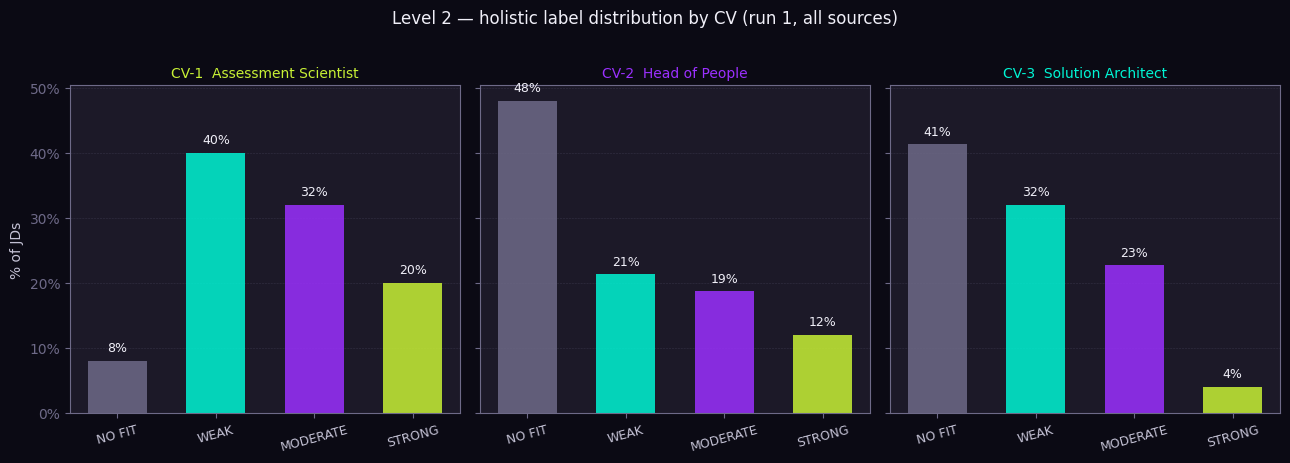

In [20]:
# Chart: holistic label distribution by CV (run 1)
HOL_LABELS = ['NO FIT', 'WEAK', 'MODERATE', 'STRONG']
HOL_COLORS = [SLATE, CYAN, VIOLET, ACID_LIME]

l2_one = l2[(l2['run_id'] == 1) & l2['error'].isna()]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
fig.patch.set_facecolor(VOID)

for ax, cv in zip(axes, CV_KEYS):
    style_axes(ax)
    sub = l2_one[l2_one['cv'] == cv]
    counts = [int((sub['holistic'] == h).sum()) for h in HOL_LABELS]
    total = sum(counts); pcts = [c / total * 100 for c in counts]
    bars = ax.bar(range(4), pcts, color=HOL_COLORS, alpha=0.85, zorder=2, width=0.6)
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{pct:.0f}%', ha='center', va='bottom', color=GHOST, fontsize=9)
    ax.set_xticks(range(4)); ax.set_xticklabels(HOL_LABELS, color=MIST, fontsize=9, rotation=15)
    ax.set_title(CV_LABELS[cv], color=CV_COLORS[cv], fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

axes[0].set_ylabel('% of JDs', color=MIST)
fig.suptitle('Level 2 — holistic label distribution by CV (run 1, all sources)', color=GHOST, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS / 'L2_holistic_dist_by_cv.png', dpi=150, bbox_inches='tight')
plt.show()

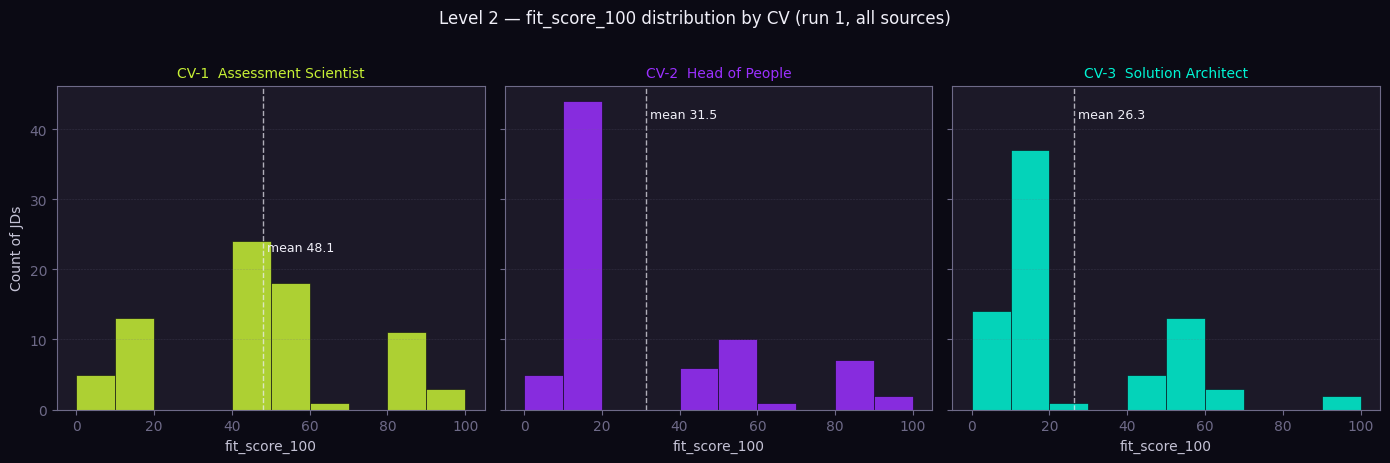

In [21]:
# Chart: fit_score_100 histogram by CV (run 1, all sources)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, sharex=True)
fig.patch.set_facecolor(VOID)

bins = np.arange(0, 101, 10)

for ax, cv in zip(axes, CV_KEYS):
    style_axes(ax)
    sub = l2_one[l2_one['cv'] == cv]
    color = CV_COLORS[cv]
    ax.hist(sub['fit_score_100'], bins=bins, color=color, alpha=0.85,
            edgecolor=VOID, linewidth=0.5)
    mean = sub['fit_score_100'].mean()
    ax.axvline(mean, color=GHOST, linestyle='--', linewidth=1, alpha=0.7)
    ax.text(mean + 1, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] else 15,
            f'mean {mean:.1f}', color=GHOST, fontsize=9)
    ax.set_title(CV_LABELS[cv], color=color, fontsize=10)
    ax.set_xlabel('fit_score_100', color=MIST)

axes[0].set_ylabel('Count of JDs', color=MIST)
fig.suptitle('Level 2 — fit_score_100 distribution by CV (run 1, all sources)', color=GHOST, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS / 'L2_dist_fit_score_by_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Reliability

Three outputs to evaluate:
* **`holistic_score`** (0–3) — LLM holistic label mapped to a 4-point integer → ICC
* **`holistic` label** — the raw 4-category label → Fleiss κ
* **`fit_score_100`** — code-computed continuous score → ICC

Both ICC(A,1) (single call — production unit) and ICC(A,k) (3-run average) are reported. 

**Note:** `fit_score_100` is a deterministic linear function of the label scores.

In [22]:
icc_l2 = pd.read_csv(ANALYSIS / 'level2_icc.csv')

print('── holistic_score (0–3) — ICC(A,1) [single call] and ICC(A,k) [mean of 3] ──')
icc_l2[icc_l2['scenario'].str.startswith('holistic_score_0-3')][
    ['cv', 'n_subjects', 'icc_1', 'icc_1_ci_low', 'icc_1_ci_high',
     'value', 'ci_low', 'ci_high', 'sem', 'interpretation']
].rename(columns={'cv':'CV', 'n_subjects':'N',
                  'icc_1':'ICC(A,1)', 'icc_1_ci_low':'CI Low (1)', 'icc_1_ci_high':'CI High (1)',
                  'value':'ICC(A,k)', 'ci_low':'CI Low (k)', 'ci_high':'CI High (k)',
                  'sem':'SEM', 'interpretation':'Interp.'})

── holistic_score (0–3) — ICC(A,1) [single call] and ICC(A,k) [mean of 3] ──


,CV,N,"ICC(A,1)",CI Low (1),CI High (1),"ICC(A,k)",CI Low (k),CI High (k),SEM,Interp.
0,ALL,224,0.967,0.96,0.97,0.989,0.99,0.99,0.108,excellent
1,cv_primary,75,0.949,0.93,0.97,0.982,0.97,0.99,0.117,excellent
2,cv_hr,75,0.977,0.97,0.98,0.992,0.99,0.99,0.095,excellent
3,cv_engineer,74,0.954,0.93,0.97,0.984,0.98,0.99,0.111,excellent


In [23]:
print('── holistic label (categorical) — Fleiss κ + agreement % ──')
icc_l2[icc_l2['scenario'].str.startswith('holistic_label')][
    ['cv', 'n_subjects', 'value', 'pct_unanimous', 'pct_majority', 'interpretation']
].rename(columns={'cv':'CV', 'n_subjects':'N', 'value':'Fleiss κ',
                  'pct_unanimous':'% Unanimous', 'pct_majority':'% Majority',
                  'interpretation':'Interp.'})

── holistic label (categorical) — Fleiss κ + agreement % ──


,CV,N,Fleiss κ,% Unanimous,% Majority,Interp.
4,ALL,224,0.905,89.7,100.0,almost perfect
5,cv_primary,75,0.883,88.0,100.0,almost perfect
6,cv_hr,75,0.921,92.0,100.0,almost perfect
7,cv_engineer,74,0.892,89.2,100.0,almost perfect


In [24]:
print('── fit_score_100 — ICC(A,1) [single call] and ICC(A,k) [mean of 3] ──')
icc_l2[icc_l2['scenario'].str.startswith('fit_score_100')][
    ['cv', 'n_subjects', 'icc_1', 'icc_1_ci_low', 'icc_1_ci_high',
     'value', 'ci_low', 'ci_high', 'sem', 'interpretation']
].rename(columns={'cv':'CV', 'n_subjects':'N',
                  'icc_1':'ICC(A,1)', 'icc_1_ci_low':'CI Low (1)', 'icc_1_ci_high':'CI High (1)',
                  'value':'ICC(A,k)', 'ci_low':'CI Low (k)', 'ci_high':'CI High (k)',
                  'sem':'SEM', 'interpretation':'Interp.'})

── fit_score_100 — ICC(A,1) [single call] and ICC(A,k) [mean of 3] ──


,CV,N,"ICC(A,1)",CI Low (1),CI High (1),"ICC(A,k)",CI Low (k),CI High (k),SEM,Interp.
8,ALL,224,0.968,0.96,0.97,0.989,0.99,0.99,2.809,excellent
9,cv_primary,75,0.971,0.96,0.98,0.990,0.99,0.99,2.675,excellent
10,cv_hr,75,0.984,0.98,0.99,0.995,0.99,1.00,1.948,excellent
11,cv_engineer,74,0.926,0.89,0.95,0.974,0.96,0.98,3.603,excellent


### Reliability: key findings

* **All three outputs excellent.** ICC(A,1) ≈ 0.97 for both `holistic_score` and `fit_score_100`; Fleiss κ for the raw label = 0.91. Single-call decisions (ICC(A,1)) are slightly less stable than 3-run averages (ICC(A,k) ≈ 0.99) but still in the excellent range.
* **Categorical labels reproduce as well as numbers** — forcing the LLM to pick from 4 labels did not cost reliability vs the 0–3 numeric prompt in Level 1 (also ICC(A,1) ≈ 0.97).
* **`fit_score_100` ICC is not an independent check**: the score is a deterministic linear function of four perfectly reproduced labels. Its ICC is mathematically bound to the label ICC. Reported for transparency only.

## 2.4 Criterion validity: holistic LLM score vs holistic HUMAN score

**Order of evidence:**
1. **Agreement** — % exact match, % within ±1, MAE.
   *Note:* ±1 spans 67 % of a 4-point scale, so this metric is **lenient by construction**. Exact match is the stricter view.
2. **Ordinal-scale agreement** — Weighted Cohen κ‡ (linear weights, bootstrap 95 % CI). The scale-appropriate statistic for a 4-level ordinal criterion.
3. **Rank correlation** — Spearman ρ\*  (ordinal × ordinal).
4. **Where it disagrees** — confusion matrix (verdict mode of 3 runs vs human-derived verdict).

**Note:** in this part of the analysis we compare the holistic matching score with the human score, which was also given holistically. The next section will compare agreement on the structural score.

In [104]:
# Summary table: L2 validity against human labels (scale 0–3, n=32)
val = pd.read_csv(ANALYSIS / 'level2_validity.csv')

def fmt_pct(v): return f'{v:.1f}%'
def fmt_3(v):   return f'{v:.3f}'
def fmt_bias(v): return f'+{v:.2f}' if v >= 0 else f'{v:.2f}'

rows = []
for prompt in ['L2_P0']:
    sub = val[(val['prompt'] == prompt) & (val['scale'] == 'holistic_score_0-3')]
    def get(metric):
        r = sub[sub['metric'] == metric]
        return r['value'].values[0] if len(r) else np.nan
    rows.append({
        'Prompt':            f'{prompt}',
        'Spearman ρ':        fmt_3(get('Spearman ρ')),
        'Weighted κ':        fmt_3(get('Weighted κ')),
        'MAE ↓':             fmt_3(get('MAE')),
        'Bias (LLM−human)':  fmt_bias(get('Bias (LLM−human)')),
        'Exact match':       fmt_pct(get('% exact match')),
    })

summary_df = pd.DataFrame(rows)
print('── L2 validity vs human labels (n=32, holistic score 0–3) ──')
display(summary_df)

── L2 validity vs human labels (n=32, holistic score 0–3) ──


,Prompt,Spearman ρ,Weighted κ,MAE ↓,Bias (LLM−human),Exact match
0,L2_P0,0.869,0.517,0.594,+0.59,46.9%


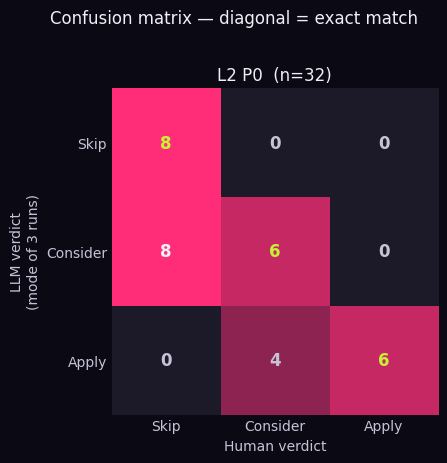

In [105]:
# ── Confusion heatmap — L2 verdict vs human (mapped to 3-level Skip/Consider/Apply) ──
VERDICT_ORDER = ['Skip', 'Consider', 'Apply']

# Map L2 holistic (4-level) → 3-level verdict, matching L1 mapping
def holistic_to_verdict(h):
    return {'NO FIT': 'Skip', 'WEAK': 'Skip',
            'MODERATE': 'Consider', 'STRONG': 'Apply'}.get(h, 'Skip')

def human_to_verdict(s):
    return {3: 'Apply', 2: 'Consider'}.get(int(s), 'Skip')

primary_main_l2 = l2[
    (l2['cv'] == 'cv_primary') & l2['human_holistic_label'].notna() & l2['error'].isna()
].copy()

agg_l2 = primary_main_l2.groupby('jd_id').agg(
    llm_holistic = ('holistic', lambda x: x.mode().iloc[0]),
    human_score  = ('human_holistic_label', 'first'),
).reset_index()
agg_l2['llm_verdict']   = agg_l2['llm_holistic'].apply(holistic_to_verdict)
agg_l2['human_verdict'] = agg_l2['human_score'].apply(human_to_verdict)

cm = pd.crosstab(agg_l2['llm_verdict'], agg_l2['human_verdict']).reindex(
    index=VERDICT_ORDER, columns=VERDICT_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
fig.patch.set_facecolor(VOID)
ax.set_facecolor(VOID)
cmap = mcolors.LinearSegmentedColormap.from_list('nh', [DEEP_SPACE, MAGENTA])
ax.imshow(cm.values, cmap=cmap, vmin=0, vmax=cm.values.max())

for i in range(3):
    for j in range(3):
        v = cm.values[i, j]
        on_diag = (i == j)
        color = ACID_LIME if on_diag and v > 0 else (GHOST if v > cm.values.max() / 2 else MIST)
        ax.text(j, i, str(v), ha='center', va='center',
                color=color, fontsize=12, fontweight='bold')

ax.set_xticks(range(3)); ax.set_xticklabels(VERDICT_ORDER, color=MIST)
ax.set_yticks(range(3)); ax.set_yticklabels(VERDICT_ORDER, color=MIST)
ax.set_xlabel('Human verdict', color=MIST)
ax.set_ylabel('LLM verdict\n(mode of 3 runs)', color=MIST)
ax.set_title(f'L2 P0  (n={len(agg_l2)})', color=GHOST)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)

fig.suptitle('Confusion matrix — diagonal = exact match', color=GHOST, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS / 'L2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Validity: key findings

* **Rank-order agreement** with human labels was very strong for the Level 2 holistic 0–3 score (Spearman ρ = 0.87).
* **Chance-corrected ordinal agreement was moderate** (weighted κ = 0.52), indicating that the system broadly reproduced human ranking patterns but with imperfect exact category alignment.
* **The model showed a systematic positive scoring bias** relative to human ratings (mean bias = +0.59), with a large paired effect size.
* Average disagreement remained below one scale point (MAE = 0.59 on a 0–3 scale), and 94% of predictions fell within ±1 of the human label.
* **Exact agreement** was achieved in 47% of JD–CV pairs, reflecting the difficulty of strict matching on a compressed 4-point ordinal scale.

## 2.4 Discriminant validity: between-CV differences

Same tests as §1.5. Two scoring outputs (`holistic_score` 0–3 and `fit_score_100`) × three JD pools — 3-way flip test.

**Sample:** same filtered subsets as Level 1:
* `main` — 16 JDs
* `hr_extra` — 18 JDs
* `engineer_extra` — 25 JDs

**Tests:**
* Friedman χ² + Kendall's *W*
* Pairwise Wilcoxon + rank-biserial *r*
* RM-ANOVA + partial η² — sensitivity check on `fit_score_100` only

**Family-wise α (Bonferroni) = 0.0083**

In [96]:
from scipy import stats
from itertools import combinations
import pingouin as pg

def aggregate_runs_l2(df, score_col):
    return df.groupby(['jd_id', 'cv'])[score_col].median().reset_index()

def pivot_wide_l2(agg, score_col):
    wide = agg.pivot(index='jd_id', columns='cv', values=score_col).dropna()
    cols = ['cv_primary', 'cv_hr', 'cv_engineer']
    cols = [c for c in cols if c in wide.columns]
    return wide[cols]

# Read and filter L2 data
l2 = pd.read_csv(ROOT / 'results' / 'level2_master.csv')
l1 = pd.read_csv(ROOT / 'results' / 'level1_master.csv')

# Get JD IDs where cv_primary has human_holistic_label >= 2 (from L1)
jds_relevant = l1[
    (l1['source'] == 'main') &
    (l1['cv'] == 'cv_primary') &
    (l1['human_holistic_label'].fillna(0) >= 2)
]['jd_id'].unique()

print(f'Level 2 discriminant validity (3-way flip test)')
print(f'Sample: main={len(jds_relevant)} (human_holistic_label >= 2), hr_extra=18, engineer_extra=25\n')

rows = []

# Analyze each subset × score_col
for subset_label, source_name, score_cols in [
    ('main', 'main', ['holistic_score', 'fit_score_100']),
    ('hr_extra', 'hr_extra', ['holistic_score', 'fit_score_100']),
    ('engineer_extra', 'engineer_extra', ['holistic_score', 'fit_score_100']),
]:
    if source_name == 'main':
        subset_df = l2[l2['jd_id'].isin(jds_relevant)].copy()
    else:
        subset_df = l2[l2['source'] == source_name].copy()
    
    for score_col in score_cols:
        agg = aggregate_runs_l2(subset_df, score_col)
        wide = pivot_wide_l2(agg, score_col)
        n, k = wide.shape
        cvs = list(wide.columns)
        
        if n < 5 or k < 2:
            continue
        
        # Friedman omnibus
        chi2, p_fri = stats.friedmanchisquare(*[wide[c].values for c in cvs])
        w = chi2 / (n * (k - 1)) if n > 0 and k > 1 else np.nan
        
        interpretation = ('large' if w >= 0.5 else 'medium' if w >= 0.3 else 
                         'small' if w >= 0.1 else 'negligible')
        
        rows.append({
            'subset': subset_label, 'score_col': score_col,
            'comparison': 'all CVs',
            'test': 'Friedman', 'n': n, 'k': k,
            'χ²': round(float(chi2), 3),
            'p_value': round(float(p_fri), 4),
            "Kendall's W": round(float(w), 3),
            'interpretation': interpretation,
        })
        
        # Pairwise Wilcoxon
        pairs = list(combinations(cvs, 2))
        denom = 6  # 3 score_cols × 3 pairs
        alpha_bon = 0.05 / denom
        for a, b in pairs:
            x, y = wide[a].values, wide[b].values
            try:
                w_stat, p_w = stats.wilcoxon(x, y)
            except ValueError:
                w_stat, p_w = 0.0, 1.0
            
            diff = np.asarray(x) - np.asarray(y)
            diff_nz = diff[diff != 0]
            if len(diff_nz) > 0:
                ranks = stats.rankdata(np.abs(diff_nz))
                sum_pos = ranks[diff_nz > 0].sum()
                sum_neg = ranks[diff_nz < 0].sum()
                total = sum_pos + sum_neg
                rbc = float((sum_pos - sum_neg) / total) if total > 0 else 0.0
            else:
                rbc = 0.0
            
            mean_diff = float(np.mean(x - y))
            sig = '*' if p_w < alpha_bon else ''
            
            rbc_interp = ('large' if abs(rbc) >= 0.5 else 'medium' if abs(rbc) >= 0.3 else
                         'small' if abs(rbc) >= 0.1 else 'negligible')
            
            rows.append({
                'subset': subset_label, 'score_col': score_col,
                'comparison': f'{a} − {b}',
                'test': 'Wilcoxon', 'n': n, 'k': 2,
                'statistic': round(float(w_stat), 3),
                'p_value': round(float(p_w), 4),
                'rank-biserial r': round(rbc, 3),
                'mean_diff': round(mean_diff, 3),
                'sig': sig,
                'interpretation': rbc_interp,
            })

out_l2 = pd.DataFrame(rows)

# Display Friedman results
print('── Friedman omnibus — do CVs differ on the same JDs? ──')
display(out_l2[out_l2['test'] == 'Friedman'][[
    'subset', 'score_col', 'n', 'χ²', 'p_value', "Kendall's W", 'interpretation'
]])

print('\n── Pairwise Wilcoxon (Bonferroni α=0.0083; * = significant) ──')
display(out_l2[out_l2['test'] == 'Wilcoxon'][[
    'subset', 'score_col', 'comparison', 'mean_diff', 'p_value', 'rank-biserial r', 'sig', 'interpretation'
]])

# Alias for compatibility with downstream cells
disc = out_l2

Level 2 discriminant validity (3-way flip test)
Sample: main=16 (human_holistic_label >= 2), hr_extra=18, engineer_extra=25

── Friedman omnibus — do CVs differ on the same JDs? ──


,subset,score_col,n,χ²,p_value,Kendall's W,interpretation
0,main,holistic_score,16,21.966,0.0,0.686,large
4,main,fit_score_100,16,20.100,0.0,0.628,large
8,hr_extra,holistic_score,18,26.358,0.0,0.732,large
12,hr_extra,fit_score_100,18,28.328,0.0,0.787,large
16,engineer_extra,holistic_score,25,35.224,0.0,0.704,large
20,engineer_extra,fit_score_100,25,20.512,0.0,0.410,medium



── Pairwise Wilcoxon (Bonferroni α=0.0083; * = significant) ──


,subset,score_col,comparison,mean_diff,p_value,rank-biserial r,sig,interpretation
1,main,holistic_score,cv_primary − cv_hr,1.312,2.000e-03,0.883,*,large
2,main,holistic_score,cv_primary − cv_engineer,1.938,3.000e-04,1.000,*,large
3,main,holistic_score,cv_hr − cv_engineer,0.625,6.670e-02,0.606,,large
5,main,fit_score_100,cv_primary − cv_hr,43.413,1.200e-03,0.950,*,large
6,main,fit_score_100,cv_primary − cv_engineer,55.725,4.000e-04,1.000,*,large
7,main,fit_score_100,cv_hr − cv_engineer,12.312,1.715e-01,0.429,,medium
9,hr_extra,holistic_score,cv_primary − cv_hr,-0.333,3.015e-01,-0.292,,small
10,hr_extra,holistic_score,cv_primary − cv_engineer,1.556,1.000e-04,1.000,*,large
11,hr_extra,holistic_score,cv_hr − cv_engineer,1.889,3.000e-04,1.000,*,large
13,hr_extra,fit_score_100,cv_primary − cv_hr,-8.478,1.757e-01,-0.410,,medium


In [60]:
import pingouin as pg

# RM-ANOVA on fit_score_100 per subset (Greenhouse-Geisser corrected)
anova_rows = []

for subset_label, source_name in [
    ('main',           'main'),
    ('hr_extra',       'hr_extra'),
    ('engineer_extra', 'engineer_extra'),
]:
    if source_name == 'main':
        subset_df = l2[l2['jd_id'].isin(jds_relevant)].copy()
    else:
        subset_df = l2[l2['source'] == source_name].copy()

    agg = aggregate_runs_l2(subset_df, 'fit_score_100')
    wide = pivot_wide_l2(agg, 'fit_score_100')
    n, k = wide.shape
    if n < 5 or k < 2:
        continue

    long = wide.reset_index().melt(id_vars='jd_id', var_name='cv', value_name='score')
    aov = pg.rm_anova(data=long, dv='score', within='cv', subject='jd_id',
                      detailed=True, correction=True)
    r = aov.iloc[0]
    ng2 = float(r['ng2'])
    interpretation = ('large' if ng2 >= 0.14 else 'medium' if ng2 >= 0.06 else
                      'small' if ng2 >= 0.01 else 'negligible')
    anova_rows.append({
        'subset':        subset_label,
        'score_col':     'fit_score_100',
        'n':             n,
        'F':             round(float(r['F']), 3),
        'p_value':       round(float(r.get('p_GG_corr', r['p_unc'])), 6),
        'partial η²':    round(ng2, 3),
        'interpretation': interpretation,
    })

anova_df = pd.DataFrame(anova_rows)
print('── RM-ANOVA sensitivity (fit_score_100; Greenhouse–Geisser corrected) ──')
display(anova_df)

── RM-ANOVA sensitivity (fit_score_100; Greenhouse–Geisser corrected) ──


,subset,score_col,n,F,p_value,partial η²,interpretation
0,main,fit_score_100,16,26.545,1.000e-06,0.576,large
1,hr_extra,fit_score_100,18,38.185,0.000e+00,0.619,large
2,engineer_extra,fit_score_100,25,17.174,3.800e-05,0.294,large



### Discriminant validity: key findings

* **Friedman omnibus tests were significant** across all JD pools for both scoring approaches (all *p* < .001), indicating that the system consistently differentiated between CVs on the same vacancies.
* **Effect sizes (Kendall’s *W*)** were generally large for both approaches.

  * `holistic_score` (0–3): main = 0.69, hr_extra = 0.73, engineer_extra = 0.70.
  * `fit_score_100` (deterministic weighted score): main = 0.63, hr_extra = 0.79, engineer_extra = 0.41.
* **The expected 3-way flip pattern was recovered under both scoring schemes**: the assessment-scientist CV scored highest on psychometric JDs, the HR CV on HR JDs, and the engineer CV on engineering JDs.
* **Pairwise contrasts showed strong separation for the target CVs**. Most significant contrasts produced very large rank-biserial correlations (*r* ≈ 0.86–1.00), indicating near-perfect ordering consistency across JD sets.
* **Non-significant contrasts occurred primarily between two non-target CVs within the same JD pool**, where partial floor overlap is expected. 
* **The two scoring approaches showed broadly similar discriminant behavior**, but with different strengths by domain. The deterministic `fit_score_100` slightly strengthened separation on HR JDs (*W* = 0.79 vs 0.73), while the direct 0–3 `holistic_score` showed stronger separation on engineering JDs (*W* = 0.70 vs 0.41).
* **Sensitivity analysis using repeated-measures ANOVA on `fit_score_100` produced the same substantive conclusions**. Greenhouse–Geisser corrected models remained highly significant across all JD pools, with large partial η² values (0.29–0.62).


# 3 Compare Holistic and Guided Evaluation

## 3.1 Score comparison: L1 P2 vs L2 P0 — scale 0–3

Both systems map to a 4-point scale with the same holistic definition. We compare them using the same metrics as criterion validity (§1.4):
* **Agreement**: % exact match, % within ±1, MAE
* **Ordinal agreement**: Weighted Cohen κ‡ (linear weights)
* **Rank correlation**: Spearman ρ\*

Note: Both score types (L1 P2 `score` and L2 P0 `holistic_score`) come from the same unified rubric instruction, so we can compare them directly on the same scale.

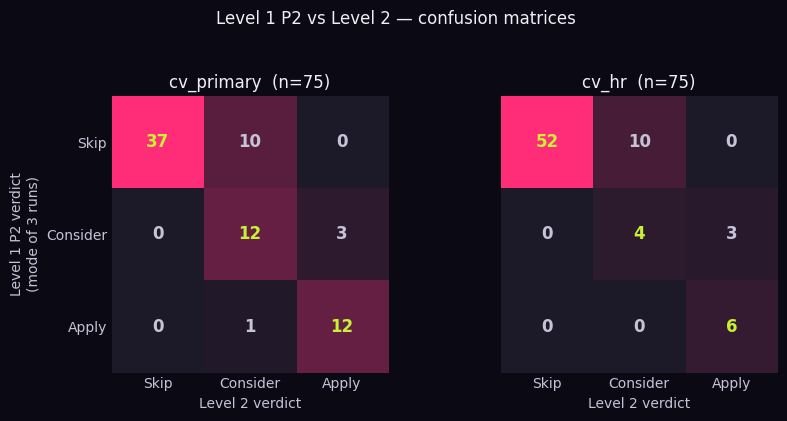

In [61]:
l2 = pd.read_csv(RESULTS / 'level2_master.csv')
l1 = pd.read_csv(RESULTS / 'level1_master.csv')
l1['level'] = 'level_1'
l2['level'] = 'level_2'


l2 = l2.rename(columns={
    'holistic_score': 'score',
    'fit_score_100': 'score_100'
})

common_cols = [
    'jd_id',
    'cv',
    'prompt',
    'run_id',
    'source',
    'model',
    'temperature',
    'score',
    'score_100',
    'human_holistic_label',
    'latency_s',
    'prompt_tokens',
    'output_tokens',
    'total_tokens',
    'error',
    'level'
]

l1_small = l1[common_cols]
l2_small = l2[common_cols]

combined = pd.concat(
    [l1_small, l2_small],
    ignore_index=True
)

combined.to_csv(RESULTS /'combined_levels.csv', index=False)

VERDICT_ORDER = ['Skip', 'Consider', 'Apply']

CV_ORDER = [
    'cv_primary',
    'cv_hr'
]


def score_to_verdict(s):
    return {
        3: 'Apply',
        2: 'Consider',
    }.get(int(s), 'Skip')


# ── Figure ─────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 4),
    sharey=True
)

fig.patch.set_facecolor(VOID)


# ── Loop through CVs ───────────────────────────────────────────

for ax, cv_name in zip(axes, CV_ORDER):

    # Level 1 P2
    l1 = combined[
        (combined['level'] == 'level_1') &
        (combined['prompt'] == 'P2') &
        (combined['cv'] == cv_name)
    ].copy()

    # Level 2
    l2 = combined[
        (combined['level'] == 'level_2') &
        (combined['cv'] == cv_name)
    ].copy()


    # score → verdict
    l1['verdict_l1'] = l1['score'].apply(score_to_verdict)
    l2['verdict_l2'] = l2['score'].apply(score_to_verdict)


    # aggregate 3 runs → mode
    l1_agg = (
        l1.groupby(['jd_id', 'cv'])
          .agg(
              verdict_l1=('verdict_l1', lambda x: x.mode().iloc[0])
          )
          .reset_index()
    )

    l2_agg = (
        l2.groupby(['jd_id', 'cv'])
          .agg(
              verdict_l2=('verdict_l2', lambda x: x.mode().iloc[0])
          )
          .reset_index()
    )


    # merge systems
    comp = l1_agg.merge(
        l2_agg,
        on=['jd_id', 'cv']
    )


    # confusion matrix
    cm = pd.crosstab(
        comp['verdict_l1'],
        comp['verdict_l2']
    ).reindex(
        index=VERDICT_ORDER,
        columns=VERDICT_ORDER,
        fill_value=0
    )


    # ── Plot ───────────────────────────────────────────────────

    ax.set_facecolor(VOID)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'nh',
        [DEEP_SPACE, MAGENTA]
    )

    im = ax.imshow(
        cm.values,
        cmap=cmap,
        vmin=0,
        vmax=cm.values.max()
    )


    # numbers inside cells
    for i in range(3):
        for j in range(3):

            v = cm.values[i, j]

            on_diag = (i == j)

            color = (
                ACID_LIME if on_diag and v > 0
                else (GHOST if v > cm.values.max()/2 else MIST)
            )

            ax.text(
                j, i,
                str(v),
                ha='center',
                va='center',
                color=color,
                fontsize=12,
                fontweight='bold'
            )


    # axes
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))

    ax.set_xticklabels(VERDICT_ORDER, color=MIST)
    ax.set_yticklabels(VERDICT_ORDER, color=MIST)

    ax.set_xlabel('Level 2 verdict', color=MIST)

    ax.set_title(
        f'{cv_name}  (n={len(comp)})',
        color=GHOST
    )

    for s in ax.spines.values():
        s.set_visible(False)

    ax.tick_params(length=0)


# shared ylabel
axes[0].set_ylabel(
    'Level 1 P2 verdict\n(mode of 3 runs)',
    color=MIST
)

fig.suptitle(
    'Level 1 P2 vs Level 2 — confusion matrices',
    color=GHOST,
    fontsize=12,
    y=1.04
)

plt.tight_layout()

plt.savefig(
    ANALYSIS / 'L1P2_vs_L2_confusion_by_cv.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### 3.2 Verdict agreement (0–3 scale mapped to Skip/Consider/Apply)

We also compare the derived verdicts (thresholds: score 0 → Skip, 1 → Consider, 2–3 → Apply) to see agreement at the decision level.

**Note:** The cv_engineer column is missing because the original L1 P2 dataset lacks sufficient verdict data for that profile (most engineer-JD pairs scored 0, producing empty contingency table). Only cv_primary and cv_hr are shown.

In [77]:
# L1 P2 vs L2 P0 — score 0-100 comparison
l1_p2 = l1[l1['prompt'] == 'P2'].copy()   # L1 P2 prompt only
l2_p0 = l2.copy()                          # L2 has no prompt variants

In [78]:
# L1 P2 vs L2 P0 — score 0-3 comparison
from scipy import stats
from sklearn.metrics import cohen_kappa_score

l1_agg = l1_p2.groupby(['jd_id', 'cv']).agg({'score': 'median'}).reset_index()
l1_agg = l1_agg.rename(columns={'score': 'l1_score'})
l2_agg = l2_p0.groupby(['jd_id', 'cv']).agg({'score': 'median'}).reset_index()
l2_agg = l2_agg.rename(columns={'score': 'l2_score'})
comp_03 = l1_agg.merge(l2_agg, on=['jd_id', 'cv']).dropna(subset=['l1_score', 'l2_score'])

print(f'Sample for score 0–3 comparison: n = {len(comp_03)} (JD, CV) pairs\n')

exact_match = (comp_03['l1_score'] == comp_03['l2_score']).sum() / len(comp_03) * 100
within_1    = (np.abs(comp_03['l1_score'] - comp_03['l2_score']) <= 1).sum() / len(comp_03) * 100
mae         = np.abs(comp_03['l1_score'] - comp_03['l2_score']).mean()

print('── Agreement (score 0–3) ──')
print(f'% exact match:  {exact_match:.1f}%')
print(f'% within ±1:    {within_1:.1f}%')
print(f'MAE:            {mae:.3f}\n')

# Weighted Cohen κ (linear) — manual bootstrap CI
kappa_val = cohen_kappa_score(
    comp_03['l1_score'].values.astype(int),
    comp_03['l2_score'].values.astype(int),
    weights='linear'
)
rng = np.random.default_rng(42)
n = len(comp_03)
l1s = comp_03['l1_score'].values.astype(int)
l2s = comp_03['l2_score'].values.astype(int)
boot_kappas = []
for _ in range(2000):
    idx = rng.integers(0, n, n)
    try:
        boot_kappas.append(cohen_kappa_score(l1s[idx], l2s[idx], weights='linear'))
    except: pass
kappa_ci = (float(np.percentile(boot_kappas, 2.5)), float(np.percentile(boot_kappas, 97.5)))

print('── Weighted Cohen κ (linear) ──')
print(f'κ = {kappa_val:.3f}  [95% CI {kappa_ci[0]:.3f}, {kappa_ci[1]:.3f}]\n')

# Spearman ρ with manual bootstrap CI
rho, p_rho = stats.spearmanr(comp_03['l1_score'], comp_03['l2_score'])
boot_rhos2 = []
for _ in range(2000):
    idx = rng.integers(0, n, n)
    boot_rhos2.append(stats.spearmanr(l1s[idx], l2s[idx])[0])
rho_ci2 = (float(np.percentile(boot_rhos2, 2.5)), float(np.percentile(boot_rhos2, 97.5)))

print('── Spearman ρ ──')
print(f'ρ = {rho:.3f}  p = {p_rho:.4f}  [95% CI {rho_ci2[0]:.3f}, {rho_ci2[1]:.3f}]')
r, p_r = stats.pearsonr(comp_03['l1_score'], comp_03['l2_score'])
print(f'Pearson r = {r:.3f}  p = {p_r:.4f}  (supplementary)')

Sample for score 0–3 comparison: n = 75 (JD, CV) pairs

── Agreement (score 0–3) ──
% exact match:  72.0%
% within ±1:    100.0%
MAE:            0.280

── Weighted Cohen κ (linear) ──
κ = 0.735  [95% CI 0.620, 0.829]

── Spearman ρ ──
ρ = 0.890  p = 0.0000  [95% CI 0.808, 0.945]
Pearson r = 0.901  p = 0.0000  (supplementary)


## 3.2 Score comparison: L1 P2 vs L2 P0 (scale 0–100)

**Important note on comparability:** Both systems output a 0–100 score, but they come from different sources:
- **L1 P2** (`score_100`): LLM directly assigns a 0–100 value in a single step
- **L2 P0** (`fit_score_100`): code calculates from categorical labels using a fixed weighted formula (0.6·skill + 0.3·(role/domain) + 0.1·edu)

Even though the instruction rubric is the same holistic rubric for both, the *mechanism* differs — L1 is direct judgment, L2 is formula-derived. We test:
1. **Paired t-test** — is there a systematic difference in means?
2. **Spearman ρ** — is there a rank-order correlation?
3. **Bland-Altman plot** — where and by how much do they diverge?

In [106]:
# L1 P2 vs L2 P0 — score 0-100 comparison
l1_agg_100 = l1_p2.groupby(['jd_id', 'cv']).agg({'score_100': 'median'}).reset_index()
l1_agg_100 = l1_agg_100.rename(columns={'score_100': 'l1_score_100'})

l2_agg_100 = l2_p0.groupby(['jd_id', 'cv']).agg({'score_100': 'median'}).reset_index()
l2_agg_100 = l2_agg_100.rename(columns={'score_100': 'l2_score_100'})

comp_100 = l1_agg_100.merge(l2_agg_100, on=['jd_id', 'cv']).dropna()
print(f'Sample: n = {len(comp_100)} (JD × CV) pairs\n')

# ── 1. ICC(A,1) — primary agreement ──────────────────────────────────────────
long_icc = comp_100.copy()
long_icc['pair'] = long_icc['jd_id'] + '__' + long_icc['cv']
long_icc = long_icc.melt(id_vars='pair',
                          value_vars=['l1_score_100', 'l2_score_100'],
                          var_name='rater', value_name='score')
icc_res = pg.intraclass_corr(data=long_icc, targets='pair', raters='rater', ratings='score')
icc_a1 = icc_res[icc_res['Type'] == 'ICC(A,1)'].iloc[0]
ci = icc_a1['CI95']
print('── ICC(A,1) — absolute agreement (primary) ──')
print(f'ICC(A,1) = {icc_a1["ICC"]:.3f}  [95% CI {ci[0]:.3f}, {ci[1]:.3f}]  p = {icc_a1["pval"]:.2e}')
interp = ('excellent' if icc_a1["ICC"] >= 0.90 else 'good' if icc_a1["ICC"] >= 0.75 else
          'moderate' if icc_a1["ICC"] >= 0.50 else 'poor')
print(f'Interpretation: {interp}\n')

# ── 2. Paired t-test — mean shift ────────────────────────────────────────────
diff = comp_100['l1_score_100'] - comp_100['l2_score_100']
mean_diff = diff.mean()
sd_diff   = diff.std()
se_diff   = sd_diff / np.sqrt(len(diff))
t_stat, p_t = stats.ttest_rel(comp_100['l1_score_100'], comp_100['l2_score_100'])
print('── Paired t-test — mean shift ──')
print(f'L1 mean: {comp_100["l1_score_100"].mean():.1f}   L2 mean: {comp_100["l2_score_100"].mean():.1f}')
print(f'Δ = {mean_diff:.2f}  SE = {se_diff:.2f}   t = {t_stat:.3f}   p = {p_t:.4f}')
print('  → No significant mean shift' if p_t >= 0.05 else '  → Significant mean shift')
print()

# ── 3. Pearson r — linear association ────────────────────────────────────────
r_val, p_r = stats.pearsonr(comp_100['l1_score_100'], comp_100['l2_score_100'])
rng = np.random.default_rng(42)
n = len(comp_100)
boot_r = [stats.pearsonr(
    comp_100['l1_score_100'].values[idx],
    comp_100['l2_score_100'].values[idx])[0]
    for idx in (rng.integers(0, n, n) for _ in range(2000))]
r_ci = (float(np.percentile(boot_r, 2.5)), float(np.percentile(boot_r, 97.5)))
print('── Pearson r — linear association ──')
print(f'r = {r_val:.3f}   p = {p_r:.4f}   [95% CI {r_ci[0]:.3f}, {r_ci[1]:.3f}]')
print(f'MAE = {np.abs(diff).mean():.2f}   RMSE = {np.sqrt((diff**2).mean()):.2f}\n')


Sample: n = 75 (JD × CV) pairs

── ICC(A,1) — absolute agreement (primary) ──
ICC(A,1) = 0.915  [95% CI 0.870, 0.950]  p = 9.98e-32
Interpretation: excellent

── Paired t-test — mean shift ──
L1 mean: 28.8   L2 mean: 31.2
Δ = -2.43  SE = 1.25   t = -1.942   p = 0.0559
  → No significant mean shift

── Pearson r — linear association ──
r = 0.918   p = 0.0000   [95% CI 0.871, 0.951]
MAE = 9.23   RMSE = 11.06



## 3.3 Trade-off summary: L1 P2 vs L2 P0

#### Agreement between the two approaches

* **0–3 scores showed strong agreement** across 75 JD×CV pairs: 72% exact match, 100% within ±1, and low average disagreement (MAE = 0.28).
* **Weighted Cohen’s κ was substantial-to-high** (κ = 0.74, 95% CI [0.62, 0.83]), indicating strong ordinal agreement beyond chance.
* **Rank ordering was highly consistent** between systems (Spearman ρ = 0.89).

#### Agreement on the 0–100 scale

* **Absolute agreement was excellent** for the continuous 0–100 scores (ICC(A,1) = 0.92, 95% CI [0.87, 0.95]).
* **No significant mean shift was detected** between systems (paired *t*-test: Δ = -2.43, *p* = .056), suggesting that the two approaches operate on broadly similar score levels.
* **Linear association was very high** (Pearson *r* = 0.92), with moderate absolute disagreement (MAE = 9.23; RMSE = 11.06).

#### Trade-offs between Level 1 and Level 2

* **Level 1 P2 achieved the highest single-call reliability** (ICC(A,1) = 0.984), slightly exceeding both Level 2 outputs (~0.97).
* **Level 1 P2 also showed stronger discriminant separation** on the psychometric JD subset (Kendall’s *W* = 0.79 vs 0.69 / 0.63 for Level 2).
* **Efficiency differences were modest in token cost** (≈2.8% cheaper for L1 P2), but substantial in latency (7.8s vs 16.3s per call).
* **Level 2’s main advantage is auditability and re-weighting flexibility**: because the structured labels are preserved separately from the final score, scoring formulas can be modified without re-running the LLM.

#### Agreement with human rates: cross-level comparison

* Both approaches showed strong alignment with human judgments, with very strong rank-order correlations across all prompts and levels (Spearman ρ ≈ 0.82–0.87).
* **Level 1 P2 achieved the strongest overall agreement** profile on the 0–3 scale, combining the highest weighted κ (0.62), lowest MAE (0.47), lowest bias (+0.41), and highest exact-match rate (56%).
* Level 2 preserved rank ordering slightly better (ρ = 0.87 vs 0.85 for L1 P2) but produced larger positive score inflation relative to human ratings.
* The practical differences between approaches were moderate rather than dramatic: both systems reproduced human ordering reliably, while differing mainly in calibration, interpretability, and auditability.


In [107]:
# Build trade-off table: extract key metrics from pre-computed results
icc_l1 = pd.read_csv(ANALYSIS / 'level1_icc.csv')
icc_l2 = pd.read_csv(ANALYSIS / 'level2_icc.csv')
val_l1 = pd.read_csv(ANALYSIS / 'level1_validity.csv')
val_l2 = pd.read_csv(ANALYSIS / 'level2_validity.csv')

# ── ICC(A,1) for score 0-3 (pooled) per L1 prompt ─────────────────────────────
def get_l1_icc_03(prompt):
    return icc_l1[
        (icc_l1['prompt'] == prompt) &
        (icc_l1['scenario'].str.contains('score_0-3')) &
        (icc_l1['cv'] == 'ALL')
    ]['icc_1'].values[0]

l1_icc_p0_03 = get_l1_icc_03('P0')
l1_icc_p1_03 = get_l1_icc_03('P1')
l1_icc_p2_03 = get_l1_icc_03('P2')

l1_icc_p2_100 = icc_l1[
    (icc_l1['prompt'] == 'P2') &
    (icc_l1['scenario'].str.contains('score_0-100')) &
    (icc_l1['cv'] == 'ALL')
]['icc_1'].values[0]

l2_icc_holistic = icc_l2[
    (icc_l2['scenario'].str.contains('holistic_score_0-3')) &
    (icc_l2['cv'] == 'ALL')
]['icc_1'].values[0]
l2_icc_fit = icc_l2[
    (icc_l2['scenario'].str.contains('fit_score_100')) &
    (icc_l2['cv'] == 'ALL')
]['icc_1'].values[0]

# ── Validity metrics per prompt (holistic 0-3) ────────────────────────────────
def get_val(val_df, prompt, metric):
    r = val_df[(val_df['prompt'] == prompt) &
               (val_df['scale'] == 'holistic_score_0-3') &
               (val_df['metric'] == metric)]
    return r['value'].values[0] if len(r) else np.nan

# ── Discriminant W (filtered main) per L1 prompt ──────────────────────────────
def get_l1_w(prompt):
    return out_l1[
        (out_l1['subset'] == 'main') &
        (out_l1['prompt'] == prompt) &
        (out_l1['test'] == 'Friedman')
    ]["Kendall's W"].values[0]

l1_w_p0 = get_l1_w('P0')
l1_w_p1 = get_l1_w('P1')
l1_w_p2 = get_l1_w('P2')

l2_w_holistic = out_l2[
    (out_l2['subset'] == 'main') &
    (out_l2['score_col'] == 'holistic_score') &
    (out_l2['test'] == 'Friedman')
]["Kendall's W"].values[0]

# ── Efficiency ────────────────────────────────────────────────────────────────
def l1_tokens_latency(prompt):
    sub = l1[l1['prompt'] == prompt]
    return sub['total_tokens'].mean(), sub['latency_s'].mean()

l1_p0_tokens, l1_p0_latency = l1_tokens_latency('P0')
l1_p1_tokens, l1_p1_latency = l1_tokens_latency('P1')
l1_p2_tokens, l1_p2_latency = l1_tokens_latency('P2')
l2_tokens   = l2_p0['total_tokens'].mean()
l2_latency  = l2_p0['latency_s'].mean()

# ── Table 1: full trade-off summary ───────────────────────────────────────────
trade_off_data = {
    'Metric': [
        'ICC(A,1) (0–3)',
        'ICC(A,1) (0–100)',
        'Spearman ρ vs human (0–3)',
        'Kendall W (discriminant)',
        'Tokens/call',
        'Latency (s)',
        'Auditability'
    ],
    'L1 P0': [
        f'{l1_icc_p0_03:.3f}',
        '—',
        f'{get_val(val_l1, "P0", "Spearman ρ"):.3f}',
        f'{l1_w_p0:.3f}',
        f'{l1_p0_tokens:.0f}',
        f'{l1_p0_latency:.2f}',
        'Score only'
    ],
    'L1 P1': [
        f'{l1_icc_p1_03:.3f}',
        '—',
        f'{get_val(val_l1, "P1", "Spearman ρ"):.3f}',
        f'{l1_w_p1:.3f}',
        f'{l1_p1_tokens:.0f}',
        f'{l1_p1_latency:.2f}',
        'Score only'
    ],
    'L1 P2': [
        f'{l1_icc_p2_03:.3f}',
        f'{l1_icc_p2_100:.3f}',
        f'{get_val(val_l1, "P2", "Spearman ρ"):.3f}',
        f'{l1_w_p2:.3f}',
        f'{l1_p2_tokens:.0f}',
        f'{l1_p2_latency:.2f}',
        'Score only'
    ],
    'L2 P0': [
        f'{l2_icc_holistic:.3f}',
        f'{l2_icc_fit:.3f}',
        f'{get_val(val_l2, "L2_P0", "Spearman ρ"):.3f}',
        f'{l2_w_holistic:.3f}',
        f'{l2_tokens:.0f}',
        f'{l2_latency:.2f}',
        'Full audit trail'
    ],
}

trade_off_df = pd.DataFrame(trade_off_data)
print('── Trade-off table ──')
display(trade_off_df)

# ── Table 2: focused validity comparison (LLM vs human, holistic 0-3) ─────────
def fmt_3(v):   return f'{v:.3f}'
def fmt_pct(v): return f'{v:.1f}%'
def fmt_bias(v): return f'+{v:.2f}' if v >= 0 else f'{v:.2f}'

val_rows = []
for level, prompt_csv_label, prompt_display in [
    ('L1', 'P0',    'L1 P0'),
    ('L1', 'P1',    'L1 P1'),
    ('L1', 'P2',    'L1 P2'),
    ('L2', 'L2_P0', 'L2 P0'),
]:
    val_df = val_l1 if level == 'L1' else val_l2
    val_rows.append({
        'Prompt':            prompt_display,
        'Spearman ρ':        fmt_3(get_val(val_df, prompt_csv_label, 'Spearman ρ')),
        'Weighted κ':        fmt_3(get_val(val_df, prompt_csv_label, 'Weighted κ')),
        'MAE ↓':             fmt_3(get_val(val_df, prompt_csv_label, 'MAE')),
        'Bias (LLM−human)':  fmt_bias(get_val(val_df, prompt_csv_label, 'Bias (LLM−human)')),
        'Exact match':       fmt_pct(get_val(val_df, prompt_csv_label, '% exact match')),
    })

val_compare_df = pd.DataFrame(val_rows)
print('\n── Validity vs human labels (n=32, holistic score 0–3) ──')
display(val_compare_df)

── Trade-off table ──


,Metric,L1 P0,L1 P1,L1 P2,L2 P0
0,"ICC(A,1) (0–3)",0.953,0.971,0.984,0.967
1,"ICC(A,1) (0–100)",—,—,0.992,0.968
2,Spearman ρ vs human (0–3),0.823,0.821,0.849,0.869
3,Kendall W (discriminant),0.817,0.791,0.791,0.686
4,Tokens/call,2103,2215,2593,2887
5,Latency (s),8.24,5.96,7.76,16.31
6,Auditability,Score only,Score only,Score only,Full audit trail



── Validity vs human labels (n=32, holistic score 0–3) ──


,Prompt,Spearman ρ,Weighted κ,MAE ↓,Bias (LLM−human),Exact match
0,L1 P0,0.823,0.520,0.562,+0.44,46.9%
1,L1 P1,0.821,0.514,0.594,+0.47,43.8%
2,L1 P2,0.849,0.623,0.469,+0.41,56.2%
3,L2 P0,0.869,0.517,0.594,+0.59,46.9%


Detailed discussion of each is in the level-specific companion docs:
* [`level_1_holistic_evaluation.md`](../level_1_holistic_evaluation.md) — Level 1 design & limitations
* [`level_2_guided_evaluation.md`](../level_2_guided_evaluation.md) — Level 2 design & limitations


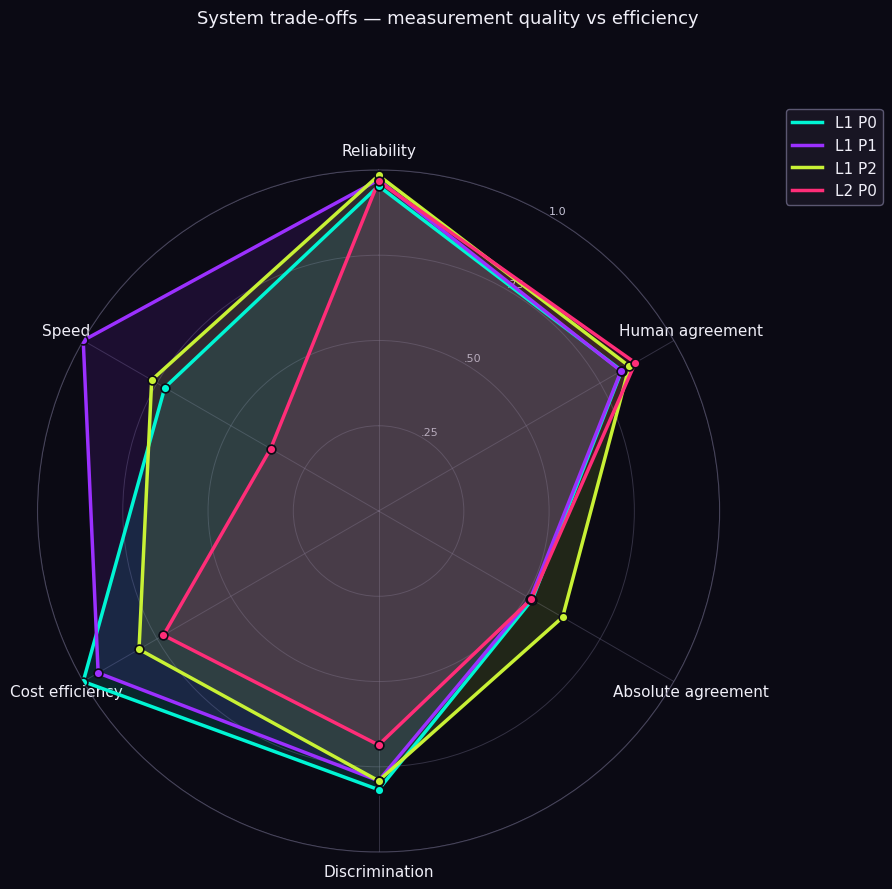

In [108]:
# ── Radar chart — visual summary of system trade-offs ────────────────────────
# Axes (all normalised 0→1, higher = better):
#   Reliability       — ICC(A,1) on 0–3
#   Human agreement   — Spearman ρ
#   Absolute agreement — Weighted κ
#   Discrimination    — Kendall W (filtered main)
#   Cost efficiency   — min_tokens / tokens (lowest tokens → 1.0)
#   Speed             — min_latency / latency (lowest latency → 1.0)

systems = [
    ('L1 P0', {
        'Reliability':       l1_icc_p0_03,
        'Human agreement':   get_val(val_l1, 'P0', 'Spearman ρ'),
        'Absolute agreement': get_val(val_l1, 'P0', 'Weighted κ'),
        'Discrimination':    l1_w_p0,
        'Cost efficiency':   l1_p0_tokens,
        'Speed':             l1_p0_latency,
    }),
    ('L1 P1', {
        'Reliability':       l1_icc_p1_03,
        'Human agreement':   get_val(val_l1, 'P1', 'Spearman ρ'),
        'Absolute agreement': get_val(val_l1, 'P1', 'Weighted κ'),
        'Discrimination':    l1_w_p1,
        'Cost efficiency':   l1_p1_tokens,
        'Speed':             l1_p1_latency,
    }),
    ('L1 P2', {
        'Reliability':       l1_icc_p2_03,
        'Human agreement':   get_val(val_l1, 'P2', 'Spearman ρ'),
        'Absolute agreement': get_val(val_l1, 'P2', 'Weighted κ'),
        'Discrimination':    l1_w_p2,
        'Cost efficiency':   l1_p2_tokens,
        'Speed':             l1_p2_latency,
    }),
    ('L2 P0', {
        'Reliability':       l2_icc_holistic,
        'Human agreement':   get_val(val_l2, 'L2_P0', 'Spearman ρ'),
        'Absolute agreement': get_val(val_l2, 'L2_P0', 'Weighted κ'),
        'Discrimination':    l2_w_holistic,
        'Cost efficiency':   l2_tokens,
        'Speed':             l2_latency,
    }),
]

axes_labels = ['Reliability', 'Human agreement', 'Absolute agreement',
               'Discrimination', 'Cost efficiency', 'Speed']

# Normalise: invert tokens and latency so lower = better → higher score
all_tokens   = [s[1]['Cost efficiency'] for s in systems]
all_latency  = [s[1]['Speed']           for s in systems]
min_tokens   = min(all_tokens)
min_latency  = min(all_latency)

def normalise(d):
    out = dict(d)
    out['Cost efficiency'] = min_tokens  / d['Cost efficiency']
    out['Speed']           = min_latency / d['Speed']
    return out

normed = [(name, normalise(metrics)) for name, metrics in systems]

# Radar setup
n_axes = len(axes_labels)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]  # close the loop

system_colors = [CYAN, VIOLET, ACID_LIME, MAGENTA]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(VOID)
ax.set_facecolor(VOID)

# Gridlines & spines
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['.25', '.50', '.75', '1.0'], color=MIST, fontsize=8)
ax.set_rlabel_position(180 / n_axes)
ax.grid(color=SLATE, alpha=0.4, linewidth=0.7)
ax.spines['polar'].set_color(SLATE)
ax.spines['polar'].set_alpha(0.5)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes_labels, color=GHOST, fontsize=11)

# Plot each system
for (name, metrics), color in zip(normed, system_colors):
    values = [metrics[a] for a in axes_labels]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, label=name, zorder=3)
    ax.fill(angles, values, color=color, alpha=0.12, zorder=2)
    # marker per vertex
    ax.scatter(angles[:-1], values[:-1], color=color, s=40, zorder=4, edgecolor=VOID, linewidth=1.2)

# Legend
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10),
          facecolor=DEEP_SPACE, edgecolor=SLATE, labelcolor=GHOST, fontsize=11)

fig.suptitle('System trade-offs — measurement quality vs efficiency',
             color=GHOST, fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS / 'radar_tradeoff.png', dpi=150, bbox_inches='tight', facecolor=VOID)
plt.show()